# 03 Ergebnisse zusammenführen und auswerten

Dieses Notebook bündelt die Datenaufbereitung und die zentralen Auswertungen für den Ergebnisteil.

1. Ergebnisdateien zusammenführen und ins Long-Format überführen
2. Gruppenunterschiede zwischen virtuellen (`VI`) und realen Influencer:innen (`RI`) auswerten
3. Effektstärken nach visuellen Überkategorien darstellen
4. Zusammenhänge mit Engagement und standardisierte Modellkoeffizienten untersuchen

Die Visualisierungen verwenden durchgängig eine kontrastreiche Petrol-Rot-Palette. Ein Stern (*) kennzeichnet signifikante Gruppenunterschiede mit `p < .05`.


In [1]:
from pathlib import Path
import re
import textwrap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu, spearmanr

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

sns.set_theme(
    style='ticks',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'axes.edgecolor': '#4A4A4A',
        'axes.labelcolor': '#2B2B2B',
        'text.color': '#2B2B2B',
        'xtick.color': '#4A4A4A',
        'ytick.color': '#2B2B2B',
        'grid.color': '#D9D9D9',
        'grid.linestyle': ':',
        'grid.linewidth': 0.8,
        'font.size': 13,
        'axes.titlesize': 17,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    },
)

# Einheitliche, kontrastreiche Petrol-Rot-Palette.
PALETTE = {'VI': '#007C78', 'RI': '#C44E52'}
PALETTE_LIGHT = {'VI': '#DCEFED', 'RI': '#F4E1E2'}
NEUTRAL_COLORS = {'text': '#2B2B2B', 'grid': '#D9D9D9', 'zero': '#5A5A5A'}
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'petrol_white_red', [PALETTE['VI'], '#F7F7F5', PALETTE['RI']]
)
TYPE_DISPLAY = {'KI': 'VI', 'REAL': 'RI', 'ai': 'VI', 'real': 'RI'}


In [10]:
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != '05_notebooks':
    NOTEBOOK_DIR = Path('data/05_notebooks').resolve()

DATA_DIR = NOTEBOOK_DIR.parent
RESULTS_DIR = DATA_DIR / '04_analysis_results' / 'visual_features'

OUTPUT_WIDE_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_all_results_merged.csv'
OUTPUT_LONG_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_all_results_long.csv'
OUTPUT_GROUP_DIFF_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_group_differences.csv'
OUTPUT_ENGAGEMENT_CORR_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_engagement_correlations.csv'
OUTPUT_REGRESSION_CSV = RESULTS_DIR / '99_AI_AND_REAL_TIKTOK_VIDEOS_regression_betas.csv'

csv_files = sorted(RESULTS_DIR.glob('*.csv'))
csv_files = [p for p in csv_files if not p.name.startswith('99_')]

print(f'Found {len(csv_files)} result CSV files:')
for p in csv_files:
    print('-', p.name)


Found 15 result CSV files:
- 01_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_brightness_contrast.csv
- 02_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_saturation.csv
- 03_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_cuts.csv
- 04_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_angle_face_orientation.csv
- 05_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_camera_distance.csv
- 06_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_scene_classification.csv
- 07_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_skin_smoothness.csv
- 08_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_aesthetic_quality.csv
- 09_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_beauty_scoring.csv
- 10_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_face_emotion.csv
- 11_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_body_pose.csv
- 12_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_structural_personen_anzahl.csv
- 13_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_visual_sharpness.csv
- 14_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_camera_stability.csv
- 15_AI_AND_REAL_TIKTOK_VIDEOS

In [11]:
DISPLAY_GROUP_NAMES = {
    'brightness_contrast': 'Helligkeit und Kontrast',
    'saturation': 'Farbsättigung',
    'cuts': 'Schnittdynamik',
    'angle_face_orientation': 'Gesichtsorientierung',
    'camera_distance': 'Kameradistanz',
    'scene_classification': 'Szenenklassifikation',
    'skin_smoothness': 'Hauttextur und Hautglättung',
    'aesthetic_quality': 'Ästhetische Gesamtqualität',
    'beauty_scoring': 'Attraktivitätsbewertung',
    'face_emotion': 'Emotionale Gesichtswirkung',
    'body_pose': 'Körperhaltung und Pose',
    'structural_personen_anzahl': 'Personenanzahl',
    'visual_sharpness': 'Bildschärfe',
    'camera_stability': 'Kamerastabilität',
    'visual_filter': 'Filter-/Artefaktmerkmale',
}

DISPLAY_METRIC_NAMES = {
    'brightness_index': 'Durchschnittliche Helligkeit',
    'contrast_index': 'Bildkontrast',
    'saturation_index': 'Farbsättigung',
    'cut_count': 'Absolute Anzahl der Schnitte',
    'cuts_per_frame': 'Schnittdichte pro Frame',
    'cuts_per_second': 'Schnittdichte pro Sekunde',
    'video_duration_seconds_est': 'Geschätzte Videodauer',
    'frames_scanned': 'Analysierte Frames',
    'video_fps': 'Bildrate des Videos',
    'face_pitch_mean': 'Mittlere vertikale Gesichtsausrichtung',
    'face_yaw_mean': 'Mittlere horizontale Gesichtsausrichtung',
    'angle_face_orientation': 'Dominante Gesichtsausrichtung',
    'detected_face_frames': 'Anteil erkannter Gesichtsframes',
    'camera_distance_label': 'Dominante Kameradistanz',
    'camera_distance_confidence': 'Sicherheit der dominanten Kameradistanz',
    'camera_distance_unique_labels': 'Vielfalt erkannter Kameradistanzen',
    'scene_top1_label': 'Dominante Szene',
    'scene_top1_confidence': 'Sicherheit der dominanten Szene',
    'scene_unique_labels': 'Vielfalt erkannter Szenen',
    'emotion_major_beit': 'Dominante Emotion (Code)',
    'emotion_major_beit_readable': 'Dominante Emotion',
    'emotion_major_beit_confidence': 'Sicherheit der dominanten Emotion',
    'emotion_unique_labels': 'Vielfalt erkannter Emotionen',
    'detected_emotion_frames': 'Anteil emotional auswertbarer Frames',
    'skin_selected_sigma': 'Ausgewählte Glättungsstärke',
    'skin_texture_laplacian_var': 'Feinstruktur der Hauttextur',
    'skin_texture_highpass_var': 'Hochfrequente Hauttextur',
    'skin_texture_dog_var': 'Texturkontrast der Haut',
    'skin_smoothness_highpass_index': 'Hautglättung (Highpass)',
    'skin_smoothness_dog_index': 'Hautglättung (DoG)',
    'detected_skin_face_frames': 'Anzahl auswertbarer Hautframes',
    'aesthetic_quality_score': 'Ästhetische Qualitätsbewertung',
    'aesthetic_quality_scored_frames': 'Anzahl ästhetisch bewerteter Frames',
    'beauty_score_mean': 'Mittlere Attraktivitätsbewertung',
    'beauty_score_std': 'Streuung der Attraktivitätsbewertung',
    'beauty_detected_face_frames': 'Anzahl bewertbarer Gesichtsframes',
    'pose_orientation': 'Dominante Körperhaltung',
    'pose_confidence': 'Sicherheit der Pose',
    'detected_pose_frames': 'Anteil erkannter Pose-Frames',
    'personen_anzahl': 'Durchschnittliche Personenzahl',
    'personen_anzahl_max': 'Maximale Personenzahl',
    'detected_person_frames': 'Anteil erkannter Personenframes',
    'sharpness_laplacian_mean': 'Durchschnittliche Bildschärfe',
    'sharpness_laplacian_std': 'Streuung der Bildschärfe',
    'optical_flow_magnitude_mean': 'Durchschnittliche Bewegungsstärke',
    'optical_flow_magnitude_std': 'Streuung der Bewegungsstärke',
    'stability_index': 'Stabilitätsindex',
    'filter_strength_prob': 'Wahrscheinlichkeit für Filtereinsatz',
    'filter_strength_label': 'Dominante Filterstärke',
    'filter_strength_std': 'Streuung der Filterstärke',
}

EXCLUDED_METRICS = {
    'has_frames',
    'has_video',
    'video_has_frames',
    'video_has_video',
    'skin_selected_sigma',
    'processed_frame_count',
    'processed_frame_pairs',
    'sampled_frames_personen_anzahl',
}

EXCLUDED_LABEL_KEYWORDS = {
    'Sicherheit',
}


def use_german_umlauts(value):
    if pd.isna(value):
        return value
    text = str(value)
    replacements = {
        'Ästhetische': 'Ästhetische',
        'aesthetische': 'ästhetische',
        'aesthetisch': 'ästhetisch',
        'Qualität': 'Qualität',
        'Qualitäts': 'Qualitäts',
        'Intensitaet': 'Intensität',
        'Farbsaettigung': 'Farbsättigung',
        'Geschaetzte': 'Geschätzte',
        'Ausgewaehlte': 'Ausgewählte',
        'Glaettungsstaerke': 'Glättungsstärke',
        'Hautglaette': 'Hautglättung',
        'Glaette': 'Glätte',
        'Koerper': 'Körper',
        'Bildschaerfe': 'Bildschärfe',
        'Kamerastabilitaet': 'Kamerastabilität',
        'Attraktivitaets': 'Attraktivitäts',
        'Attraktivitaet': 'Attraktivität',
        'Bewegungsstaerke': 'Bewegungsstärke',
        'Stabilitaetsindex': 'Stabilitätsindex',
        'für': 'für',
        'Filterstaerke': 'Filterstärke',
        'hoeher': 'höher',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def feature_group_from_filename(path: Path) -> str:
    name = path.stem
    name = re.sub(r'^\d+_', '', name)
    name = re.sub(r'^AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_', '', name)
    return name


def prettify_text(value: str) -> str:
    value = value.replace('_', ' ').strip()
    value = re.sub(r'\s+', ' ', value)
    if not value:
        return value
    return use_german_umlauts(value[0].upper() + value[1:])


def pretty_group_label(feature_group: str) -> str:
    return use_german_umlauts(DISPLAY_GROUP_NAMES.get(feature_group, prettify_text(feature_group)))


def pretty_metric_label(metric_name: str) -> str:
    return use_german_umlauts(DISPLAY_METRIC_NAMES.get(metric_name, prettify_text(metric_name)))


def pretty_label(feature_group: str, metric_name: str) -> str:
    return use_german_umlauts(f"{pretty_group_label(feature_group)} | {pretty_metric_label(metric_name)}")


def feature_only_label(value: str) -> str:
    return use_german_umlauts(str(value).split('|')[-1].strip())


def cohens_d_real_minus_ai(ai_vals: pd.Series, real_vals: pd.Series) -> float:
    ai_vals = ai_vals.dropna().astype(float)
    real_vals = real_vals.dropna().astype(float)
    if len(ai_vals) < 2 or len(real_vals) < 2:
        return np.nan
    pooled_var = (
        ((len(ai_vals) - 1) * ai_vals.var(ddof=1)) + ((len(real_vals) - 1) * real_vals.var(ddof=1))
    ) / (len(ai_vals) + len(real_vals) - 2)
    if pooled_var <= 0 or pd.isna(pooled_var):
        return np.nan
    return (real_vals.mean() - ai_vals.mean()) / np.sqrt(pooled_var)


def standardize(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return series * 0.0
    return (series - series.mean()) / std


## 1. Ergebnisdateien zusammenführen

Die einzelnen Ergebnisdateien werden zu einer breiten Gesamtdatei mit allen extrahierten Merkmalen pro Video verbunden.


In [12]:
raw_frames = {path.name: pd.read_csv(path) for path in csv_files}
common_columns = sorted(set.intersection(*(set(df.columns) for df in raw_frames.values())))
merge_keys = ['video_id']

for name, df in raw_frames.items():
    duplicated = df.duplicated(subset=merge_keys).sum()
    if duplicated:
        raise ValueError(f'{name} has {duplicated} duplicate video_id values. Merge would be ambiguous.')

base_df = raw_frames[csv_files[0].name][common_columns].copy()
wide_df = base_df.copy()
merge_details = []

for path in csv_files:
    file_name = path.name
    feature_group = feature_group_from_filename(path)
    df = raw_frames[file_name].copy()
    feature_columns = [col for col in df.columns if col not in common_columns]

    prefixed = df[merge_keys + feature_columns].rename(
        columns={col: f'{feature_group}__{col}' for col in feature_columns}
    )
    wide_df = wide_df.merge(prefixed, on=merge_keys, how='left')

    merge_details.append({
        'source_file': file_name,
        'feature_group': feature_group,
        'rows': len(df),
        'feature_columns_added': len(feature_columns),
    })

merge_details_df = pd.DataFrame(merge_details)
display(merge_details_df)
print('Merged shape:', wide_df.shape)

wide_df.to_csv(OUTPUT_WIDE_CSV, index=False)
print(f'Saved merged wide CSV to {OUTPUT_WIDE_CSV}')


,source_file,feature_group,rows,feature_columns_added
0,01_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_b...,brightness_contrast,500,3
1,02_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_s...,saturation,500,2
2,03_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_c...,cuts,500,7
3,04_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_a...,angle_face_orientation,500,5
4,05_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_c...,camera_distance,500,5
5,06_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_s...,scene_classification,500,4
6,07_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_s...,skin_smoothness,500,8
7,08_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_a...,aesthetic_quality,500,3
8,09_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_b...,beauty_scoring,500,4
9,10_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_f...,face_emotion,500,6


Merged shape: (500, 114)
Saved merged wide CSV to /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/99_AI_AND_REAL_TIKTOK_VIDEOS_all_results_merged.csv


## 2. Daten ins Long-Format überführen

Das Long-Format vereinfacht Tests und Zusammenfassungsplots über viele Kategorien hinweg.

Wenn die Long-CSV bereits existiert, laedt die nächste Zelle sie direkt. Zum Neuerstellen `USE_EXISTING_LONG_CSV = False` setzen.


In [13]:
USE_EXISTING_LONG_CSV = True

if USE_EXISTING_LONG_CSV and OUTPUT_LONG_CSV.exists():
    long_df = pd.read_csv(OUTPUT_LONG_CSV)
    long_df['plot_typ'] = long_df['influencer_type'].map(TYPE_DISPLAY).fillna(long_df['influencer_type'])
    if {'feature_group', 'metric_name'}.issubset(long_df.columns):
        long_df['metric_label'] = long_df.apply(
            lambda row: pretty_label(row['feature_group'], row['metric_name']), axis=1
        )
    print(f'Loaded long CSV from {OUTPUT_LONG_CSV}')
else:
    feature_cols = [col for col in wide_df.columns if '__' in col]
    id_cols = [col for col in wide_df.columns if col not in feature_cols]

    long_df = wide_df.melt(
        id_vars=id_cols,
        value_vars=feature_cols,
        var_name='feature_full_name',
        value_name='feature_value',
    )

    long_df[['feature_group', 'metric_name']] = long_df['feature_full_name'].str.split('__', n=1, expand=True)
    long_df = long_df[~long_df['metric_name'].isin(EXCLUDED_METRICS)].copy()
    long_df['metric_label'] = long_df.apply(lambda row: pretty_label(row['feature_group'], row['metric_name']), axis=1)
    if 'use_german_umlauts' in globals():
        long_df['metric_label'] = long_df['metric_label'].map(use_german_umlauts)
    long_df = long_df[~long_df['metric_label'].str.contains('|'.join(EXCLUDED_LABEL_KEYWORDS), case=False, na=False)].copy()
    long_df['feature_value_numeric'] = pd.to_numeric(long_df['feature_value'], errors='coerce')
    long_df['plot_typ'] = long_df['influencer_type'].map(TYPE_DISPLAY).fillna(long_df['influencer_type'])

    long_df.to_csv(OUTPUT_LONG_CSV, index=False)
    print(f'Saved long CSV to {OUTPUT_LONG_CSV}')
    display(long_df.head())



Loaded long CSV from /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/99_AI_AND_REAL_TIKTOK_VIDEOS_all_results_long.csv


## 3. Gruppenunterschiede zwischen VI und RI

### 3.1 Übersichtstabelle

Die Tabelle fasst deskriptive Kennwerte, Mann-Whitney-U-Tests und Effektstärken zusammen.


In [14]:
if 'cohens_d_real_minus_ai' not in globals():
    def cohens_d_real_minus_ai(ai_vals: pd.Series, real_vals: pd.Series) -> float:
        ai_vals = ai_vals.dropna().astype(float)
        real_vals = real_vals.dropna().astype(float)
        if len(ai_vals) < 2 or len(real_vals) < 2:
            return np.nan
        pooled_var = (
            ((len(ai_vals) - 1) * ai_vals.var(ddof=1)) + ((len(real_vals) - 1) * real_vals.var(ddof=1))
        ) / (len(ai_vals) + len(real_vals) - 2)
        if pooled_var <= 0 or pd.isna(pooled_var):
            return np.nan
        return (real_vals.mean() - ai_vals.mean()) / np.sqrt(pooled_var)

numeric_long = long_df.dropna(subset=['feature_value_numeric']).copy()

group_diff_rows = []
for (feature_group, metric_name, metric_label), sub in numeric_long.groupby(['feature_group', 'metric_name', 'metric_label']):
    ai_vals = sub.loc[sub['influencer_type'] == 'ai', 'feature_value_numeric'].dropna()
    real_vals = sub.loc[sub['influencer_type'] == 'real', 'feature_value_numeric'].dropna()
    if len(ai_vals) < 5 or len(real_vals) < 5:
        continue

    try:
        u_statistic, p_value = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
    except ValueError:
        continue

    d_value = cohens_d_real_minus_ai(ai_vals, real_vals)
    group_diff_rows.append({
        'Kategorie': metric_label,
        'feature_group': feature_group,
        'metric_name': metric_name,
        'KI (M)': ai_vals.mean(),
        'REAL (M)': real_vals.mean(),
        'KI Median': ai_vals.median(),
        'REAL Median': real_vals.median(),
        'U': u_statistic,
        'p': p_value,
        'Effektgröße_d': d_value,
        'Richtung': 'REAL hoeher' if pd.notna(d_value) and d_value > 0 else ('KI hoeher' if pd.notna(d_value) and d_value < 0 else 'kein klarer Unterschied'),
        'signifikant_05': p_value < 0.05,
    })

group_diff_df = pd.DataFrame(group_diff_rows).sort_values(['signifikant_05', 'p', 'Kategorie'], ascending=[False, True, True])
if 'use_german_umlauts' in globals():
    group_diff_df['Kategorie'] = group_diff_df['Kategorie'].map(use_german_umlauts)
group_diff_df.to_csv(OUTPUT_GROUP_DIFF_CSV, index=False)
display_group_diff_df = group_diff_df[['Kategorie', 'KI (M)', 'REAL (M)', 'U', 'p', 'Effektgröße_d', 'Richtung', 'signifikant_05']].copy()
display_group_diff_df['Richtung'] = display_group_diff_df['Richtung'].replace({'REAL hoeher': 'RI höher', 'KI hoeher': 'VI höher', 'REAL höher': 'RI höher', 'KI höher': 'VI höher'})
display_group_diff_df = display_group_diff_df.rename(columns={'KI (M)': 'VI (M)', 'REAL (M)': 'RI (M)'})
display(display_group_diff_df.round(4))
print(f'Übersichtstabelle gespeichert: {OUTPUT_GROUP_DIFF_CSV}')


,Kategorie,VI (M),RI (M),U,p,Effektgröße_d,Richtung,signifikant_05
15,Schnittdynamik | Absolute Anzahl der Schnitte,3.9000,14.9520,16918.5,0.0000,0.4662,RI höher,True
18,Schnittdynamik | Analysierte Frames,523.7400,1266.3360,17856.0,0.0000,0.6760,RI höher,True
17,Schnittdynamik | Schnittdichte pro Sekunde,0.1815,0.5237,18565.5,0.0000,0.4430,RI höher,True
21,Emotionale Gesichtswirkung | Anteil emotional ...,18.5640,43.1560,18107.5,0.0000,0.6690,RI höher,True
8,Körperhaltung und Pose | Anteil erkannter Pose...,18.5640,43.1560,18107.5,0.0000,0.6690,RI höher,True
1,Ästhetische Gesamtqualität | Anzahl ästhetisch...,18.5640,43.1560,18107.5,0.0000,0.6690,RI höher,True
16,Schnittdynamik | Schnittdichte pro Frame,0.0064,0.0177,18666.0,0.0000,0.4314,RI höher,True
19,Schnittdynamik | Geschätzte Videodauer,18.1252,42.7767,18188.0,0.0000,0.6700,RI höher,True
37,Bildschärfe | Streuung der Bildschärfe,127.8197,215.5757,19517.0,0.0000,0.4075,RI höher,True
24,Szenenklassifikation | Vielfalt erkannter Szenen,3.9520,7.1920,20529.5,0.0000,0.5271,RI höher,True


Übersichtstabelle gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/99_AI_AND_REAL_TIKTOK_VIDEOS_group_differences.csv


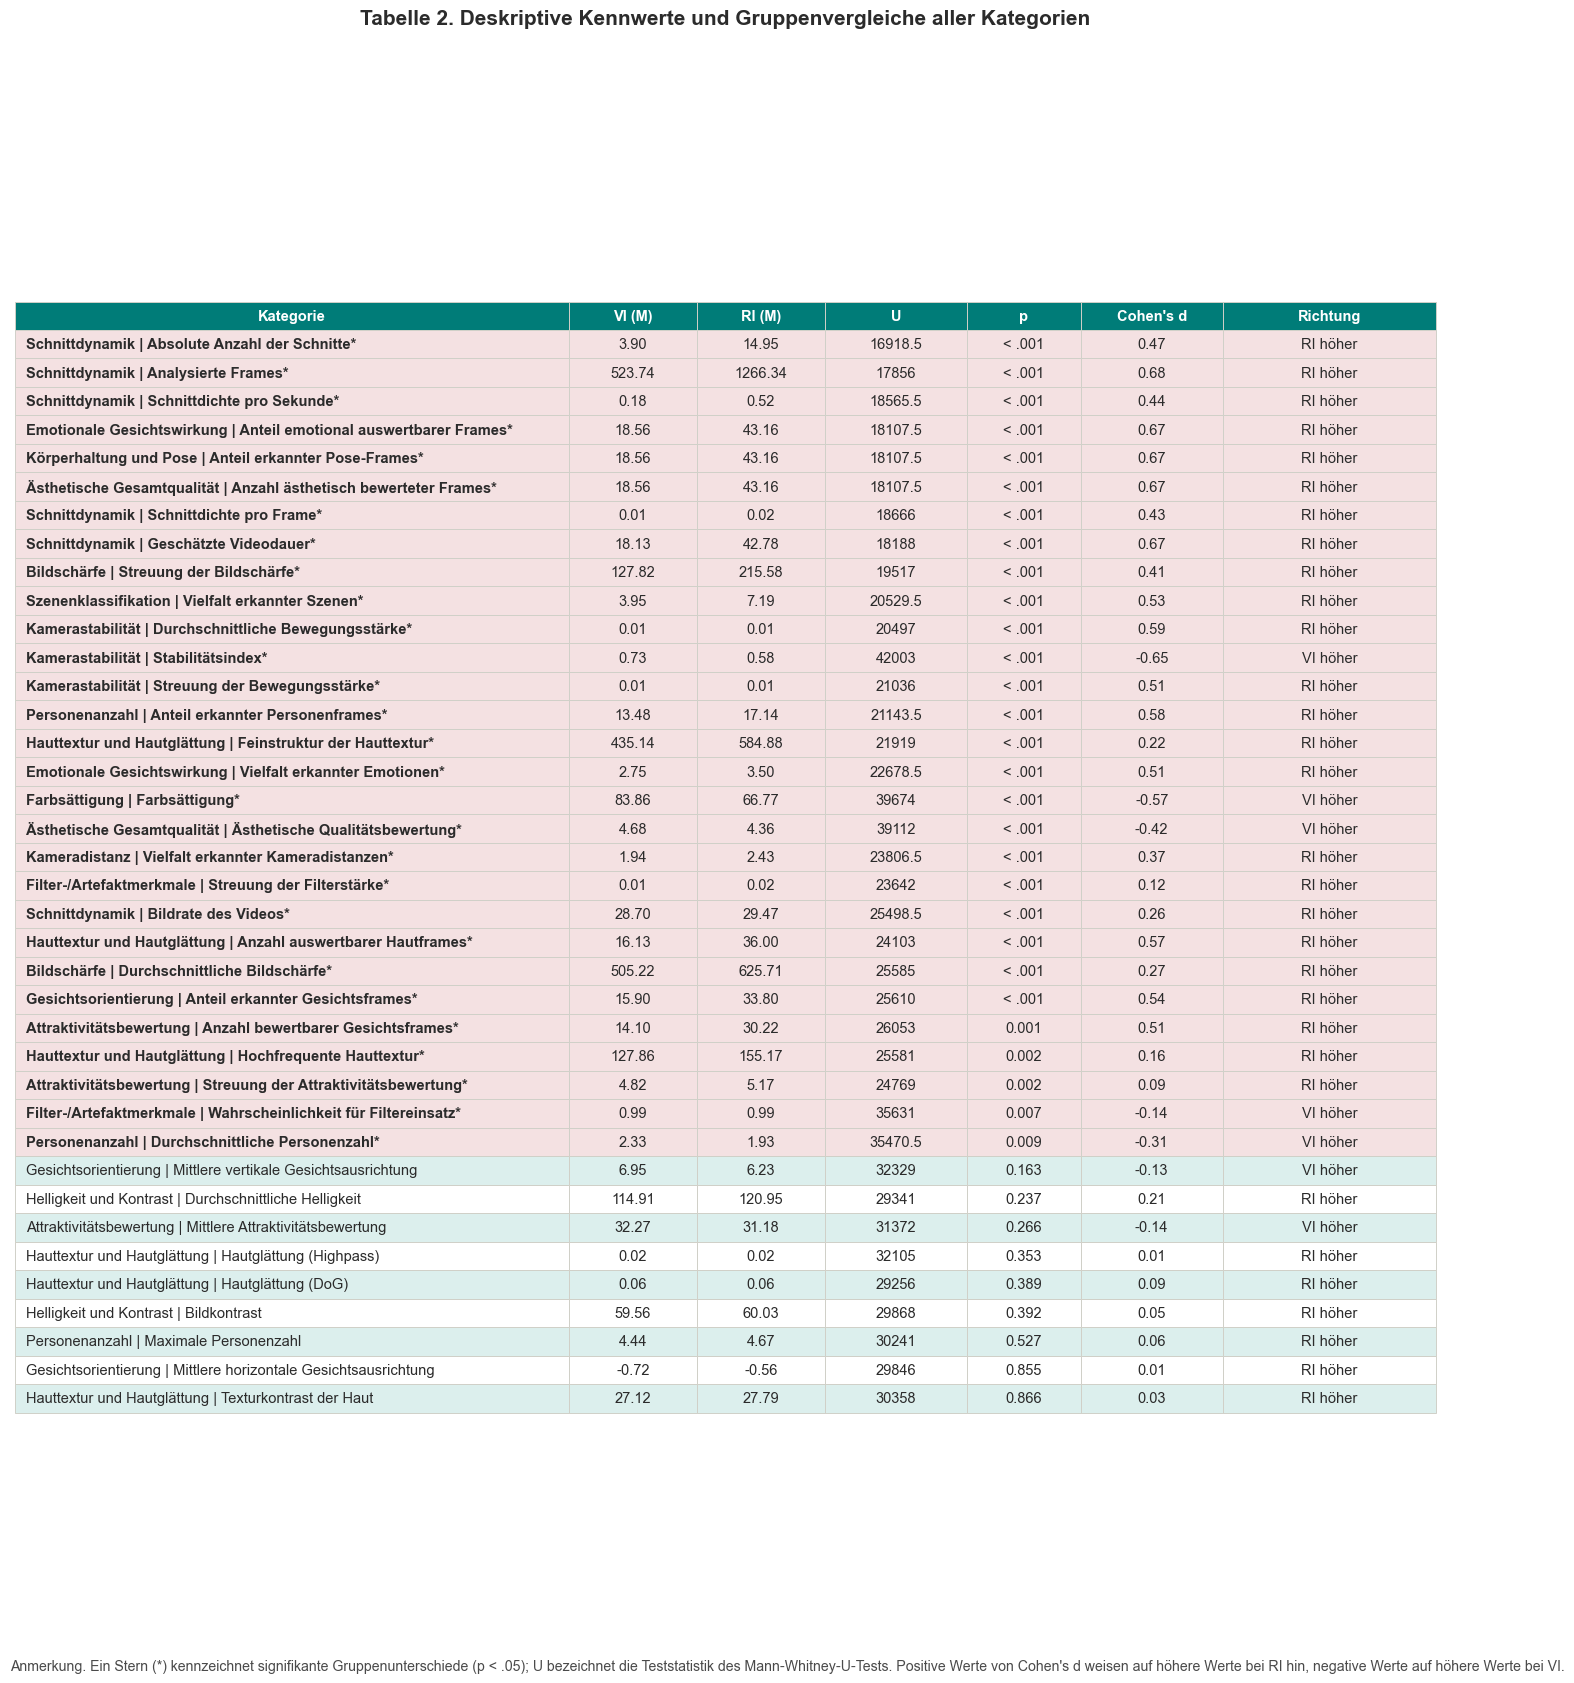

In [15]:
group_diff_table_df = group_diff_df.copy()
group_diff_table_df['KI (M)'] = group_diff_table_df['KI (M)'].map(lambda x: f"{x:.2f}" if pd.notna(x) else '')
group_diff_table_df['REAL (M)'] = group_diff_table_df['REAL (M)'].map(lambda x: f"{x:.2f}" if pd.notna(x) else '')
group_diff_table_df['U'] = group_diff_table_df['U'].map(lambda x: f"{x:.0f}" if pd.notna(x) and float(x).is_integer() else (f"{x:.1f}" if pd.notna(x) else ''))
group_diff_table_df['p'] = group_diff_table_df['p'].map(lambda x: '< .001' if pd.notna(x) and x < 0.001 else (f"{x:.3f}" if pd.notna(x) else ''))
group_diff_table_df['Effektgröße_d'] = group_diff_table_df['Effektgröße_d'].map(lambda x: f"{x:.2f}" if pd.notna(x) else '')
group_diff_table_df['Kategorie'] = group_diff_table_df.apply(
    lambda row: f"{row['Kategorie']}*" if row['signifikant_05'] else row['Kategorie'],
    axis=1,
)

group_diff_table_df['Richtung'] = group_diff_table_df['Richtung'].replace({'REAL hoeher': 'RI höher', 'KI hoeher': 'VI höher', 'REAL höher': 'RI höher', 'KI höher': 'VI höher'})
table_cols = ['Kategorie', 'KI (M)', 'REAL (M)', 'U', 'p', 'Effektgröße_d', 'Richtung']
plot_table_df = group_diff_table_df[table_cols].rename(columns={'KI (M)': 'VI (M)', 'REAL (M)': 'RI (M)', 'Effektgröße_d': "Cohen's d"})

fig_height = max(7.2, 0.40 * len(plot_table_df) + 1.8)
fig, ax = plt.subplots(figsize=(14.6, fig_height))
ax.axis('off')

col_widths = [0.39, 0.09, 0.09, 0.10, 0.08, 0.10, 0.15]
table = ax.table(
    cellText=plot_table_df.values,
    colLabels=plot_table_df.columns,
    cellLoc='center',
    colLoc='center',
    colWidths=col_widths,
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.48)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#d0d0c8')
    cell.set_linewidth(0.7)
    if row == 0:
        cell.set_facecolor(PALETTE['VI'])
        cell.set_text_props(weight='semibold', color='white')
        continue

    is_significant = group_diff_df.iloc[row - 1]['signifikant_05']
    base_color = PALETTE_LIGHT['RI'] if is_significant else ('white' if row % 2 == 1 else PALETTE_LIGHT['VI'])
    cell.set_facecolor(base_color)

    if col == 0:
        cell.set_text_props(ha='left')
        cell.PAD = 0.02
        if is_significant:
            cell.set_text_props(weight='semibold')

fig.suptitle(
    'Tabelle 2. Deskriptive Kennwerte und Gruppenvergleiche aller Kategorien',
    x=0.5,
    y=0.995,
    fontsize=15,
    fontweight='semibold',
)
fig.text(
    0.01,
    0.018,
    "Anmerkung. Ein Stern (*) kennzeichnet signifikante Gruppenunterschiede (p < .05); U bezeichnet die Teststatistik des Mann-Whitney-U-Tests. Positive Werte von Cohen's d weisen auf höhere Werte bei RI hin, negative Werte auf höhere Werte bei VI.",
    fontsize=10.2,
    color='#4a4a4a',
    ha='left',
)
plt.tight_layout(rect=[0, 0.04, 1, 0.975])
plt.show()


### 3.2 Effektstärken über alle Merkmale

Positive Werte bedeuten: `RI` höher. Negative Werte bedeuten: `VI` höher. Zusätzlich zum Gesamtplot wird ein Vergleich ohne die Überkategorie „Bildtechnische Merkmale“ ausgegeben.


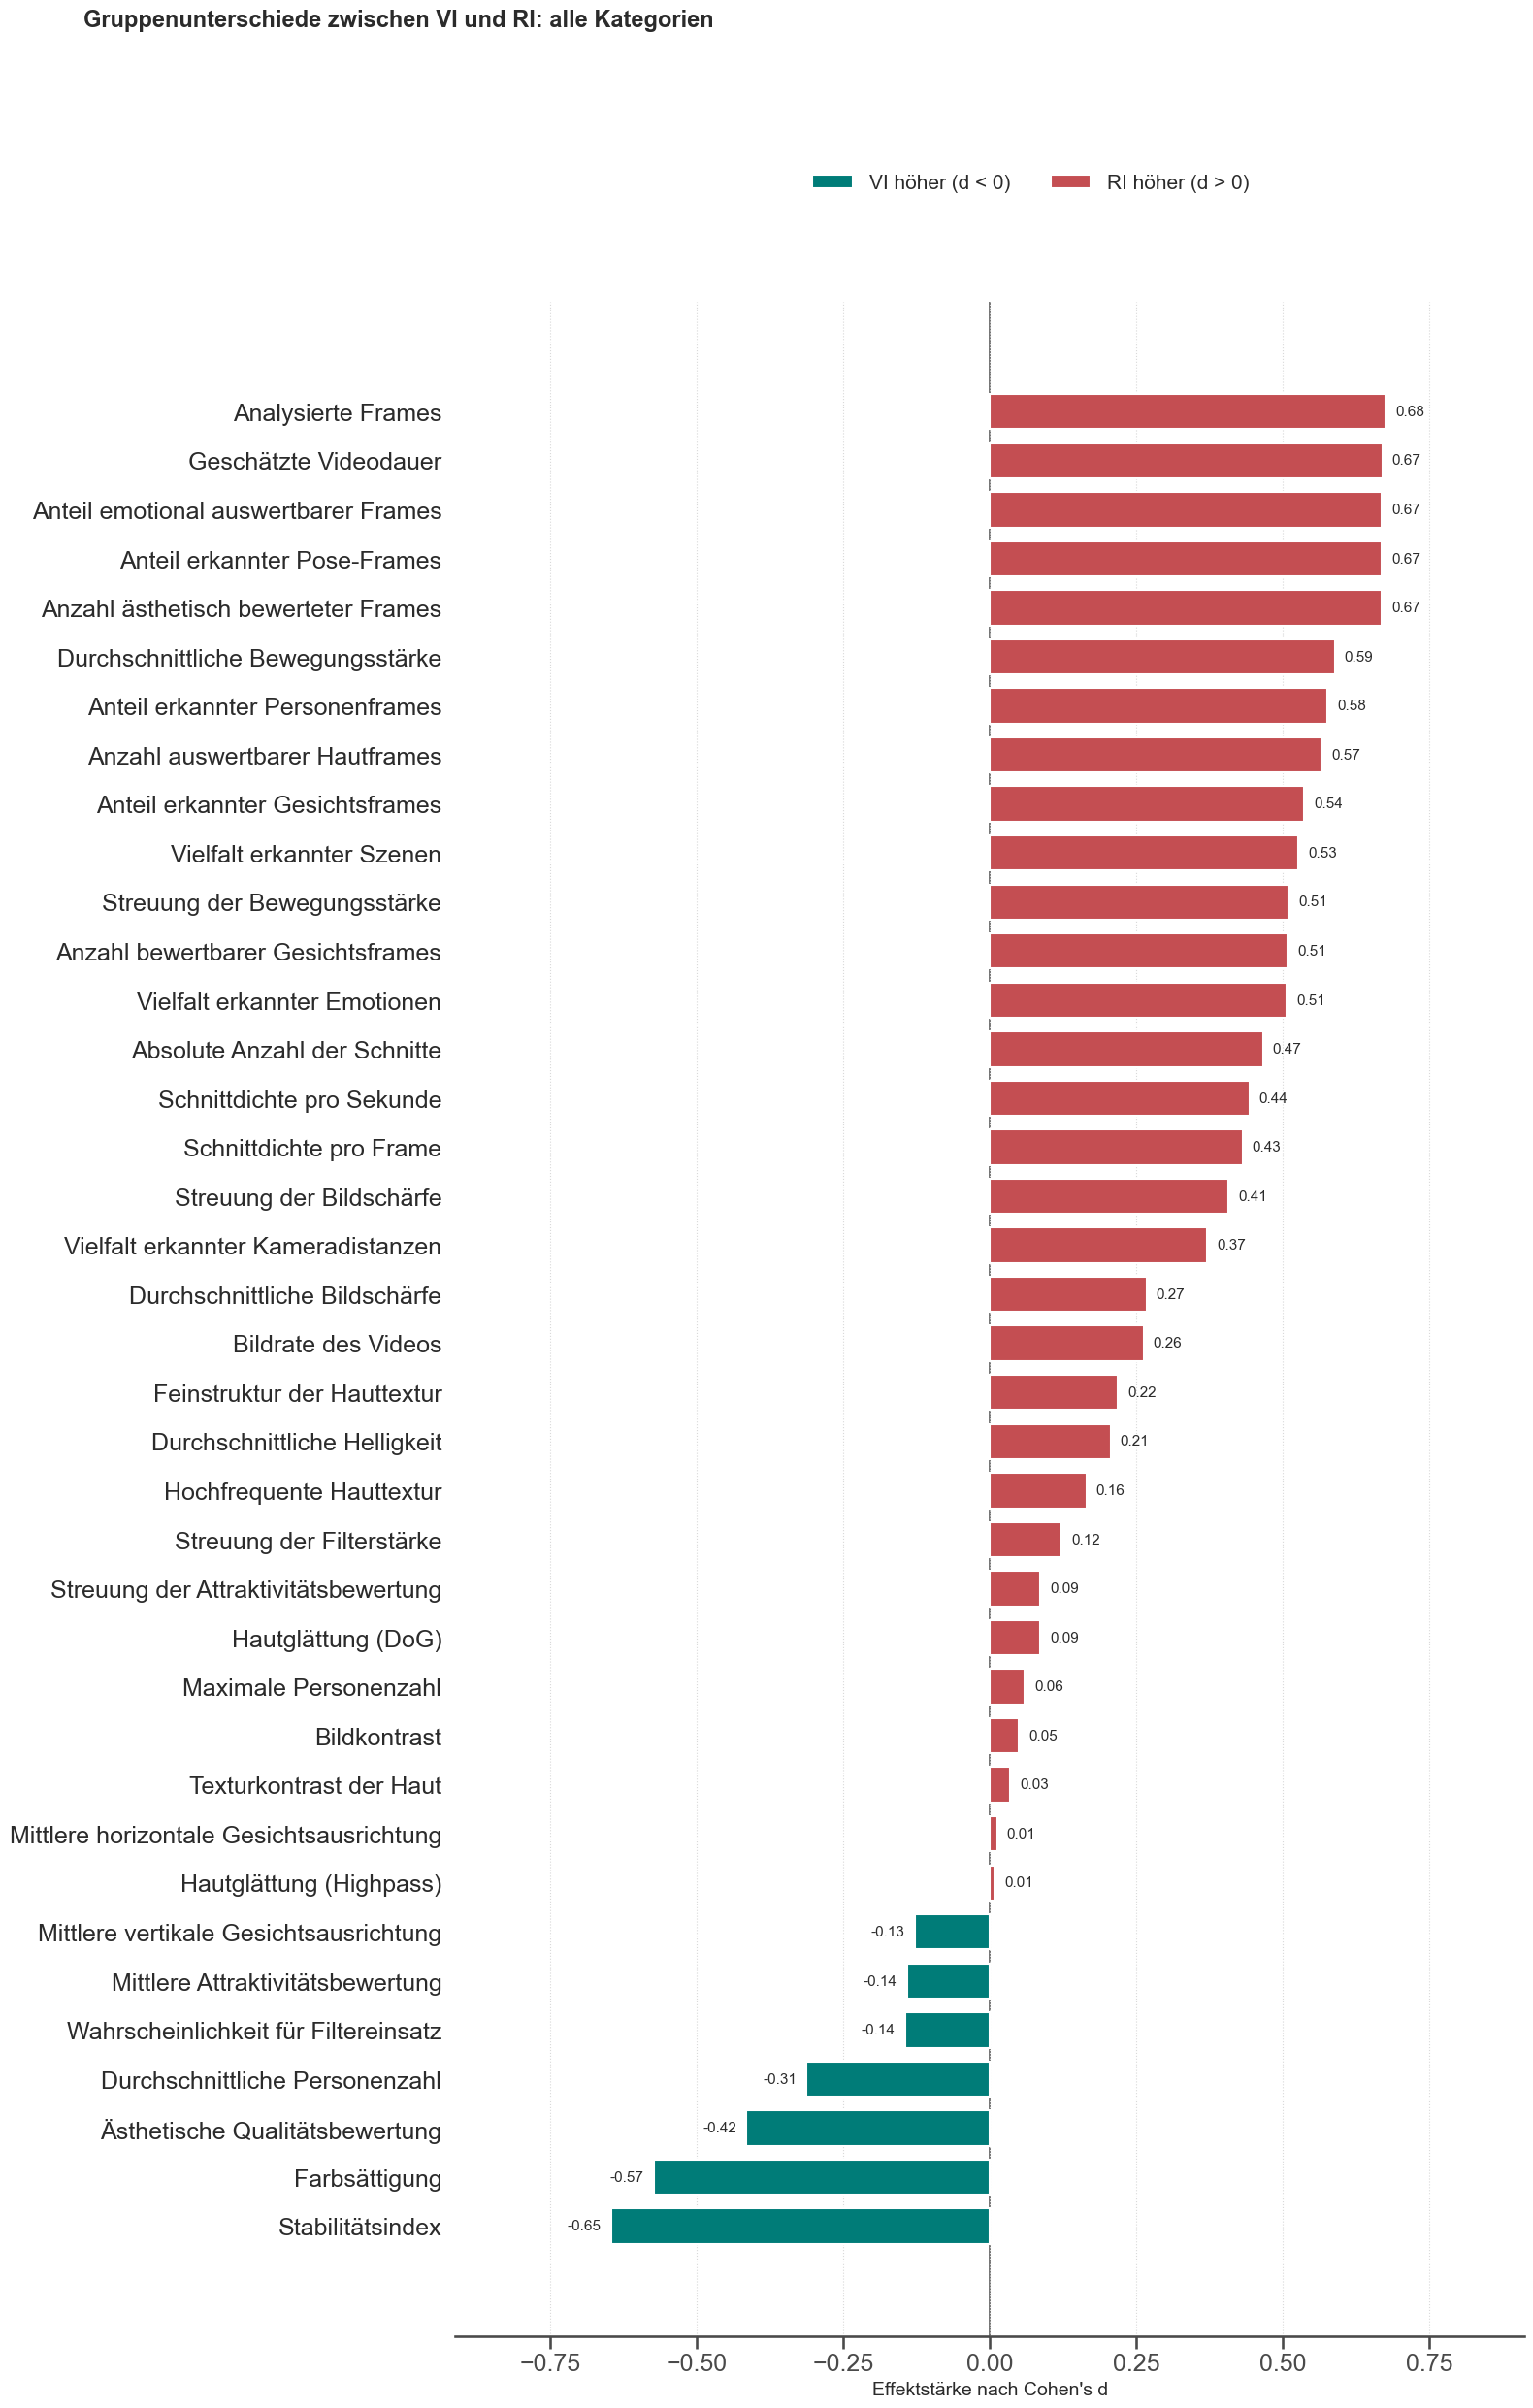

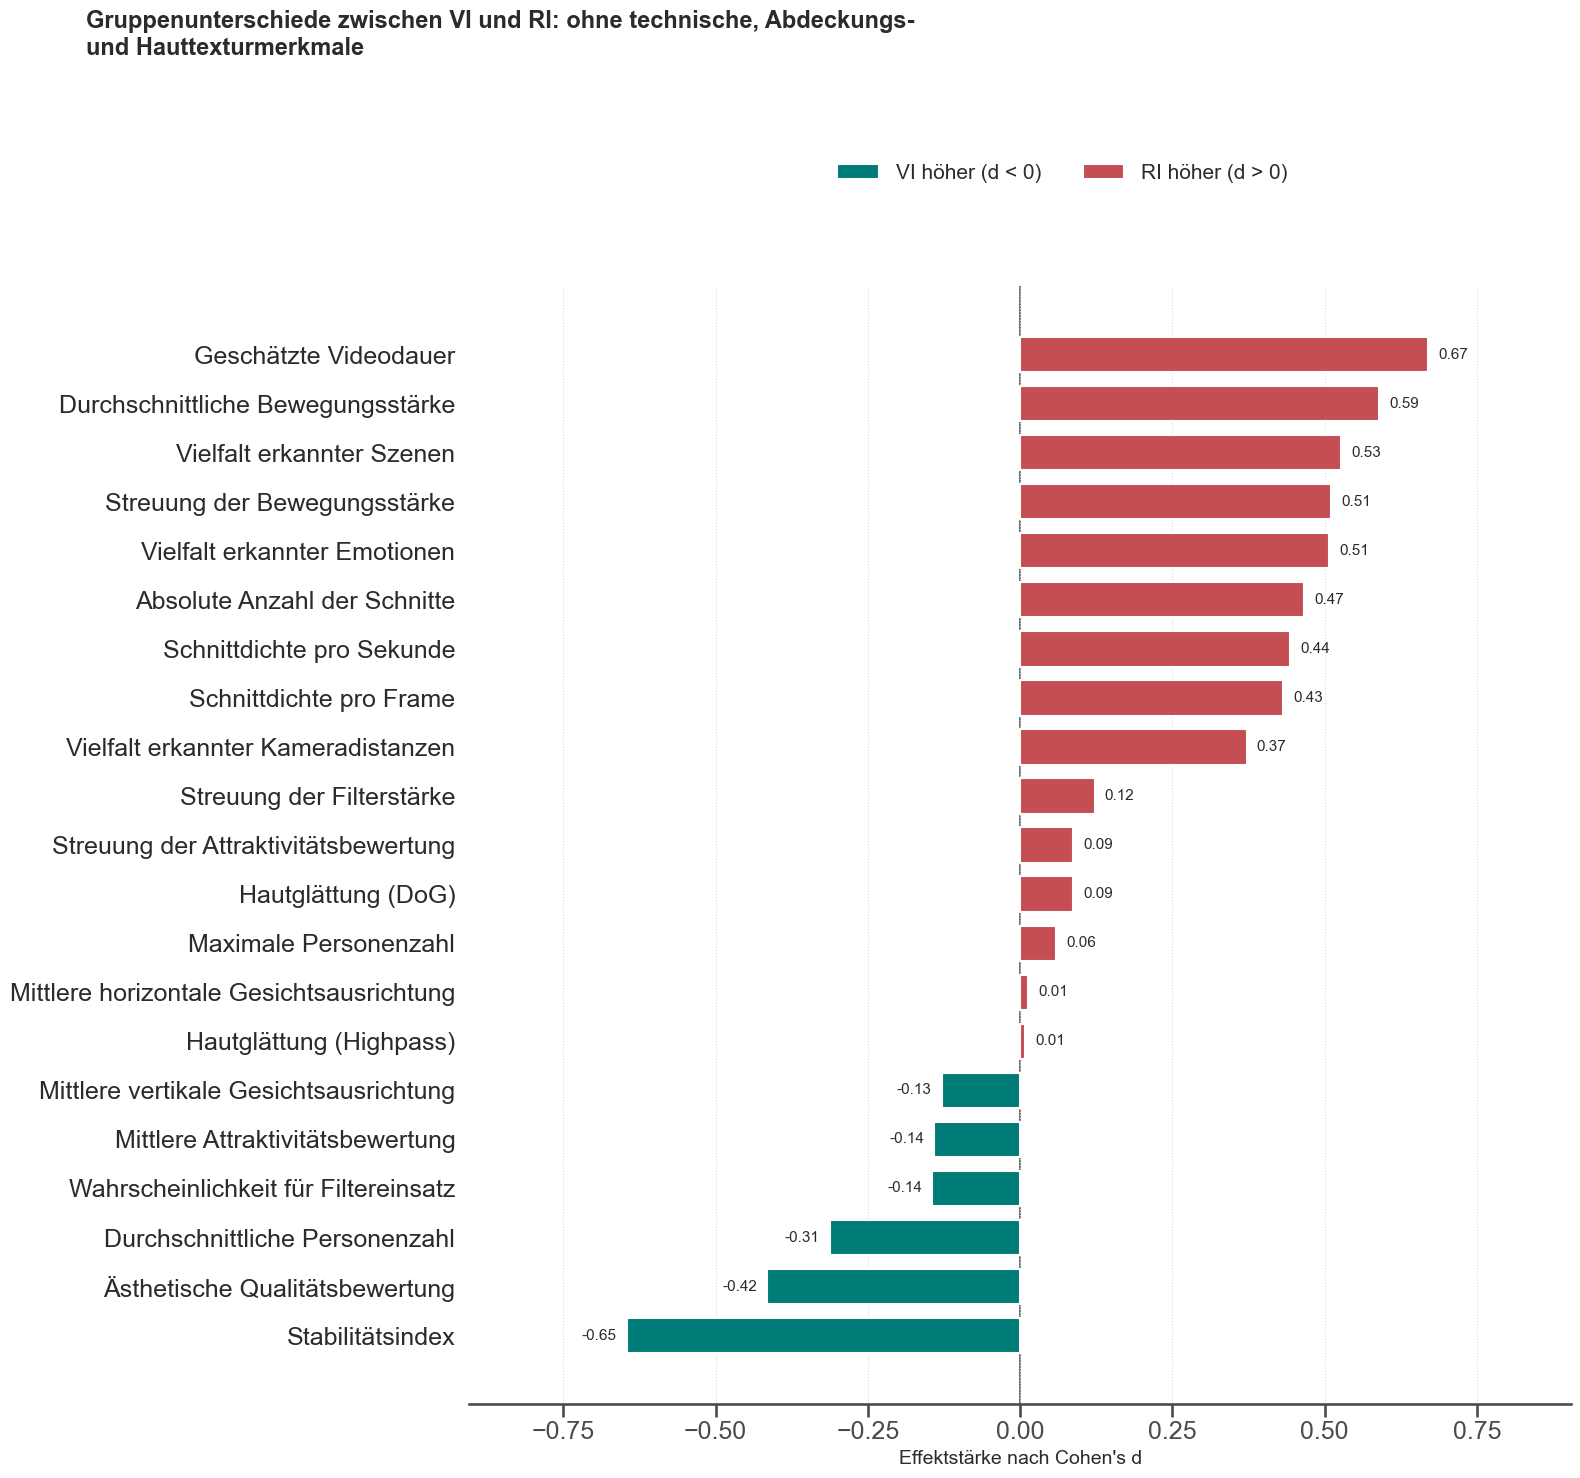

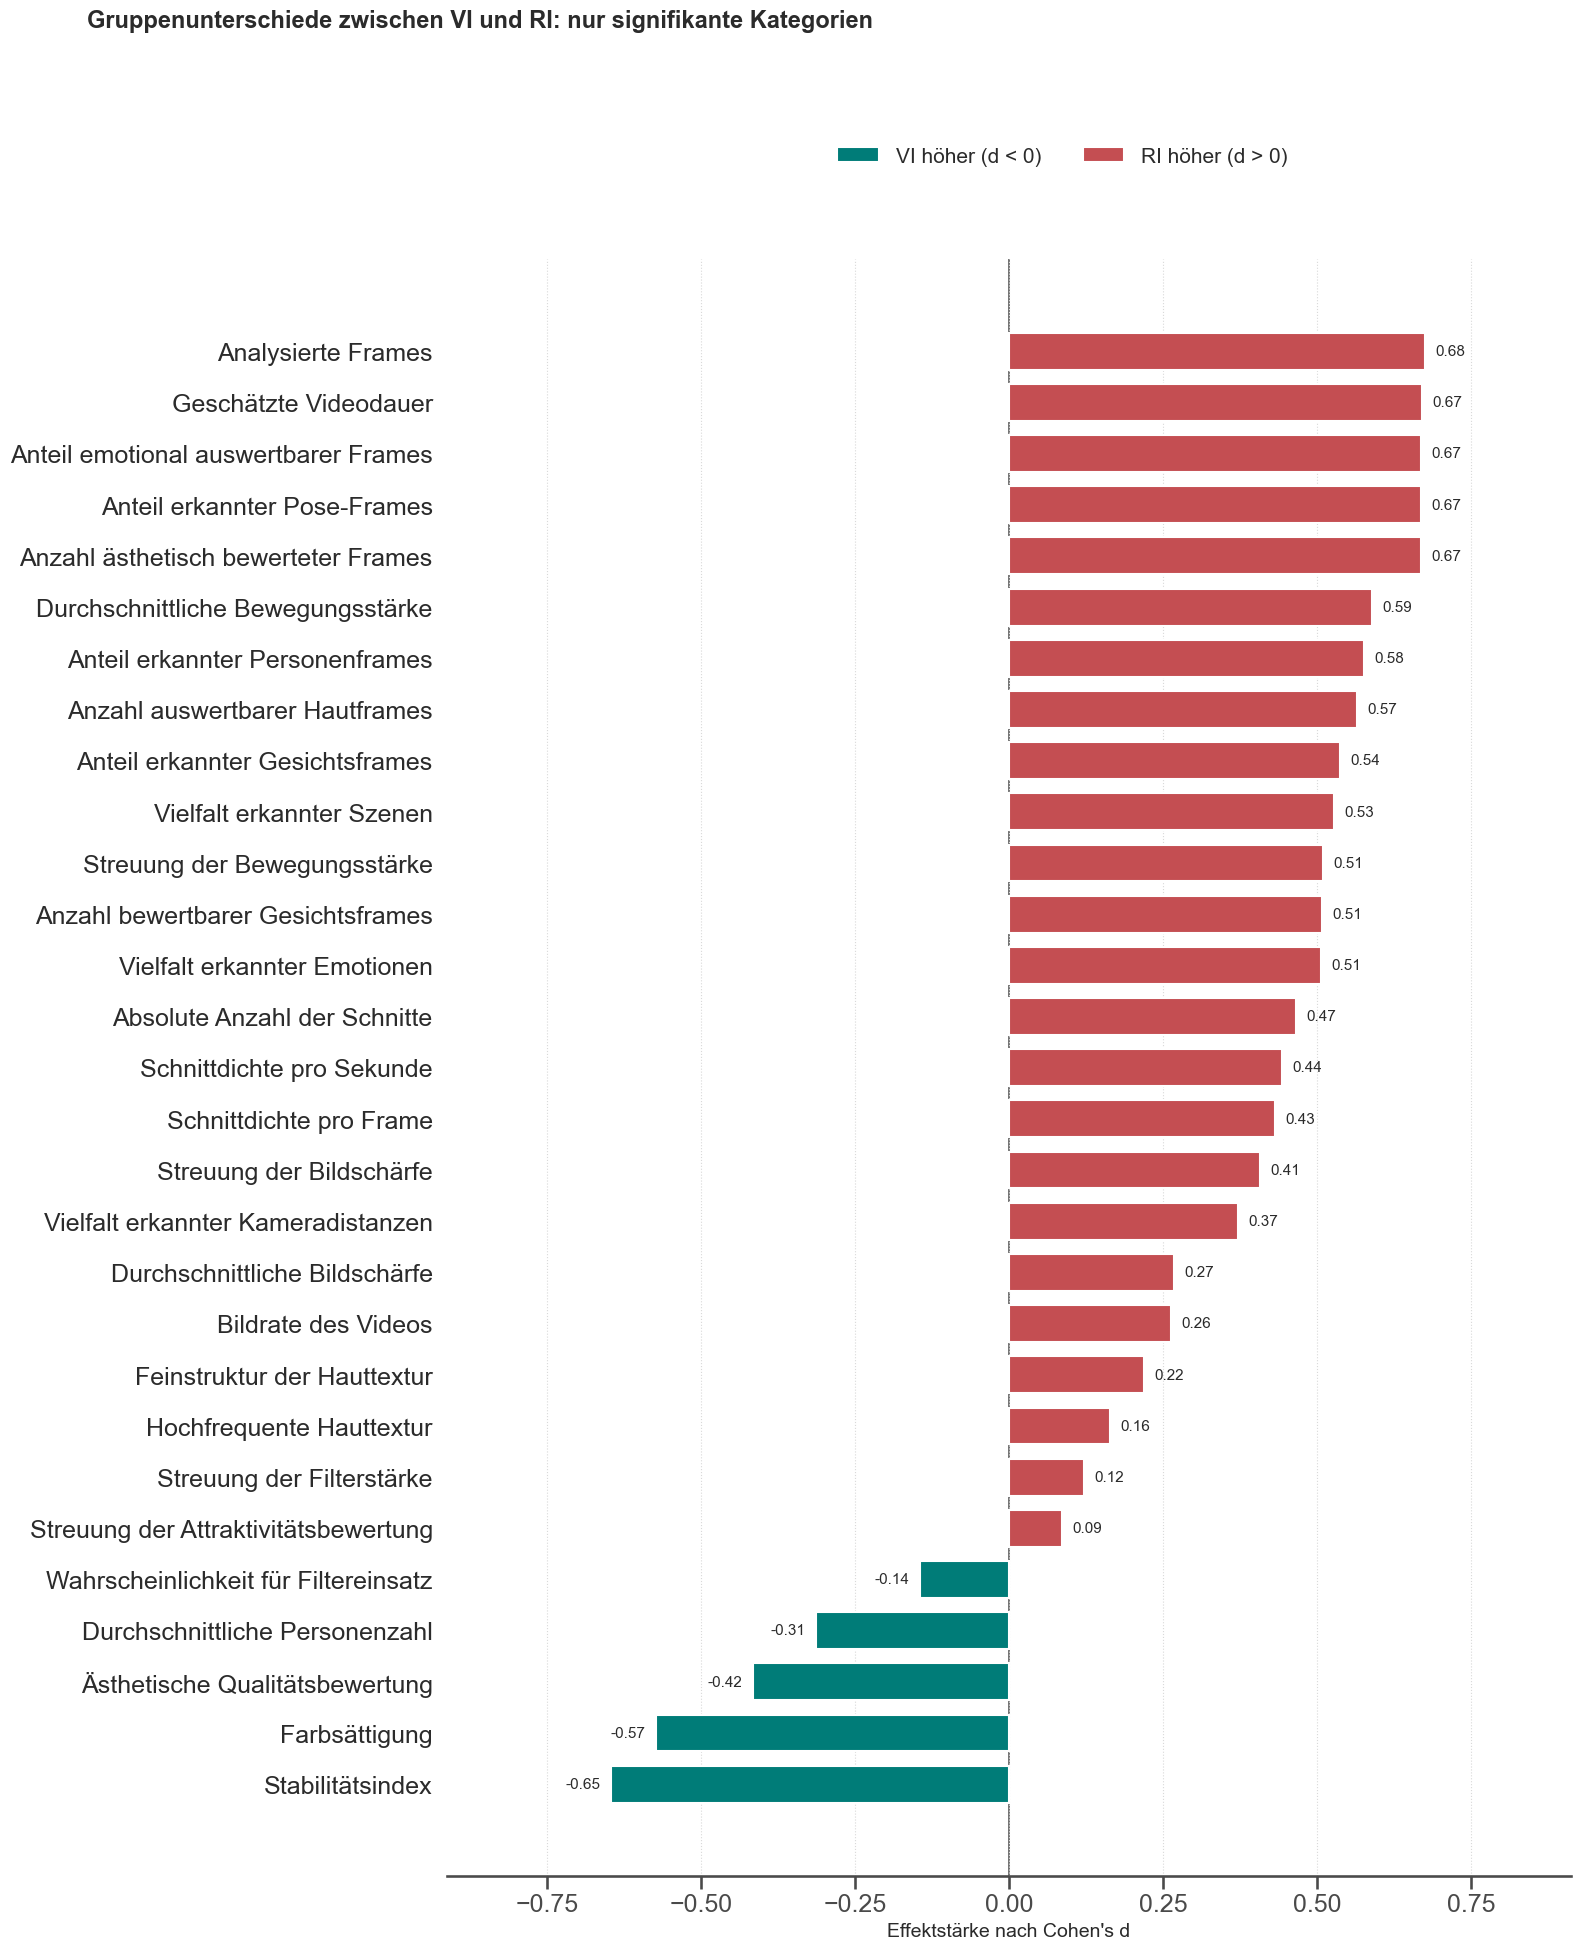

In [16]:
effect_df_all = group_diff_df.dropna(subset=['Effektgröße_d']).copy().sort_values('Effektgröße_d')
effect_df_sig = effect_df_all[effect_df_all['signifikant_05']].copy()
TECHNICAL_FEATURE_GROUPS = {'brightness_contrast', 'saturation', 'visual_sharpness'}
COVERAGE_AND_CONTEXT_METRICS = {
    'frames_scanned',
    'video_fps',
    'aesthetic_quality_scored_frames',
    'beauty_detected_face_frames',
    'detected_face_frames',
    'detected_skin_face_frames',
    'detected_emotion_frames',
    'detected_pose_frames',
    'detected_person_frames',
    'skin_texture_laplacian_var',
    'skin_texture_highpass_var',
    'skin_texture_dog_var',
}
effect_df_without_technical = effect_df_all[
    ~effect_df_all['feature_group'].isin(TECHNICAL_FEATURE_GROUPS)
    & ~effect_df_all['metric_name'].isin(COVERAGE_AND_CONTEXT_METRICS)
].copy()

def plot_effect_sizes(effect_df: pd.DataFrame, title: str):
    if effect_df.empty:
        print(f'Keine Daten für: {title}')
        return
    plot_df = effect_df.copy()
    plot_df['Kategorie_plot'] = plot_df['Kategorie'].map(
        lambda value: '\n'.join(textwrap.wrap(feature_only_label(value), width=42))
    )
    fig, ax = plt.subplots(figsize=(16, max(7.5, 0.60 * len(plot_df) + 2.4)))
    colors = np.where(plot_df['Effektgröße_d'] >= 0, PALETTE['RI'], PALETTE['VI'])
    bars = ax.barh(plot_df['Kategorie_plot'], plot_df['Effektgröße_d'], color=colors, edgecolor='white', height=0.72)
    max_abs = max(plot_df['Effektgröße_d'].abs().max(), 0.25)
    ax.set_xlim(-1.35 * max_abs, 1.35 * max_abs)
    ax.axvline(0, color=NEUTRAL_COLORS['zero'], linewidth=1.2, zorder=0)
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, plot_df['Effektgröße_d']):
        offset = 0.025 * max_abs if value >= 0 else -0.025 * max_abs
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f'{value:.2f}',
                va='center', ha='left' if value >= 0 else 'right', fontsize=11)
    legend_handles = [
        Patch(facecolor=PALETTE['VI'], label='VI höher (d < 0)'),
        Patch(facecolor=PALETTE['RI'], label='RI höher (d > 0)'),
    ]
    title_lines = textwrap.wrap(title, width=68)
    is_multiline_title = len(title_lines) > 1
    fig.suptitle(
        '\n'.join(title_lines),
        x=0.06,
        y=0.985,
        ha='left',
        va='top',
        weight='semibold',
        fontsize=17,
    )
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.67, 0.895 if is_multiline_title else 0.925),
        ncol=2,
        frameon=False,
        fontsize=15,
    )
    ax.set_xlabel("Effektstärke nach Cohen's d")
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=18, length=0, pad=10)
    ax.tick_params(axis='x', labelsize=18)
    sns.despine(ax=ax, top=True, right=True, left=True)
    plt.tight_layout(rect=[0, 0, 1, 0.86 if is_multiline_title else 0.89])
    plt.show()

plot_effect_sizes(effect_df_all, 'Gruppenunterschiede zwischen VI und RI: alle Kategorien')
plot_effect_sizes(
    effect_df_without_technical,
    'Gruppenunterschiede zwischen VI und RI: ohne technische, Abdeckungs- und Hauttexturmerkmale',
)
plot_effect_sizes(effect_df_sig, 'Gruppenunterschiede zwischen VI und RI: nur signifikante Kategorien')




### 3.3 Effektstärken nach visuellen Überkategorien

Jeder Plot zeigt Cohen's d als `RI - VI`: Positive Werte stehen für höhere Werte bei RI, negative Werte für höhere Werte bei VI. Die Farben kodieren dieselbe Richtung redundant und bleiben dadurch auch bei Farbsehschwächen gut interpretierbar.


In [22]:
if 'use_german_umlauts' not in globals():
    def use_german_umlauts(value):
        if pd.isna(value):
            return value
        text = str(value)
        replacements = {
            'Ästhetische': 'Ästhetische', 'aesthetische': 'ästhetische', 'aesthetisch': 'ästhetisch',
            'Qualität': 'Qualität', 'Qualitäts': 'Qualitäts', 'Intensitaet': 'Intensität',
            'Farbsaettigung': 'Farbsättigung', 'Geschaetzte': 'Geschätzte',
            'Ausgewaehlte': 'Ausgewählte', 'Glaettungsstaerke': 'Glättungsstärke',
            'Hautglaette': 'Hautglättung', 'Glaette': 'Glätte', 'Koerper': 'Körper',
            'Bildschaerfe': 'Bildschärfe', 'Kamerastabilitaet': 'Kamerastabilität',
            'Attraktivitaets': 'Attraktivitäts', 'Attraktivitaet': 'Attraktivität',
            'Bewegungsstaerke': 'Bewegungsstärke', 'Stabilitaetsindex': 'Stabilitätsindex',
            'für': 'für', 'Filterstaerke': 'Filterstärke', 'hoeher': 'höher',
        }
        for old, new in replacements.items():
            text = text.replace(old, new)
        return text

if 'pretty_metric_label' not in globals():
    def pretty_metric_label(metric_name: str) -> str:
        if 'DISPLAY_METRIC_NAMES' in globals():
            label = DISPLAY_METRIC_NAMES.get(metric_name)
            if label is not None:
                return use_german_umlauts(label)
        value = str(metric_name).replace('_', ' ').strip()
        value = re.sub(r'\s+', ' ', value) if 're' in globals() else ' '.join(value.split())
        return use_german_umlauts(value[0].upper() + value[1:] if value else value)


VISUAL_SUPERCATEGORIES = {
    'Strukturale Inszenierung und visuelle Dynamik': {
        'feature_groups': ['cuts', 'camera_stability', 'scene_classification', 'camera_distance'],
        'metrics': [
            'video_duration_seconds_est', 'cut_count', 'cuts_per_second',
            'optical_flow_magnitude_mean', 'optical_flow_magnitude_std', 'stability_index',
            'scene_unique_labels', 'camera_distance_unique_labels',
        ],
    },
    'Bildtechnische Merkmale': {
        'feature_groups': ['brightness_contrast', 'saturation', 'visual_sharpness'],
        'metrics': [
            'brightness_index', 'contrast_index', 'saturation_index',
            'sharpness_laplacian_mean', 'sharpness_laplacian_std',
        ],
    },
    'Ästhetische Qualität und visuelle Optimierung': {
        'feature_groups': ['aesthetic_quality', 'beauty_scoring', 'skin_smoothness', 'visual_filter'],
        'metrics': [
            'filter_strength_prob',
            'filter_strength_std',
            'skin_smoothness_highpass_index',
            'skin_smoothness_dog_index',
            'beauty_score_mean',
            'beauty_score_std',
            'aesthetic_quality_score',
        ],
    },
    'Emotionale und soziale Präsenz': {
        'feature_groups': ['angle_face_orientation', 'face_emotion', 'body_pose', 'structural_personen_anzahl'],
        'metrics': [
            'face_pitch_mean', 'face_yaw_mean',
            'emotion_unique_labels',
            'personen_anzahl', 'personen_anzahl_max',
        ],
    },
}

SUPERCATEGORY_TITLES = {
    'Strukturale Inszenierung und visuelle Dynamik': 'Visuelle Dynamik',
    'Bildtechnische Merkmale': 'Bildtechnik',
    'Ästhetische Qualität und visuelle Optimierung': 'Ästhetik',
    'Emotionale und soziale Präsenz': 'Emotion/Präsenz',
}

PLOT_GROUP_LABELS = {
    'camera_stability': 'Kamerastabilität',
    'cuts': 'Schnittdynamik',
    'camera_distance': 'Kameradistanz',
    'scene_classification': 'Szenenklassifikation',
    'brightness_contrast': 'Helligkeit und Kontrast',
    'saturation': 'Farbsättigung',
    'visual_sharpness': 'Bildschärfe',
    'visual_filter': 'Filter-/Artefaktmerkmale',
    'skin_smoothness': 'Hauttextur und Hautglättung',
    'beauty_scoring': 'Attraktivitätsbewertung',
    'aesthetic_quality': 'Ästhetische Gesamtqualität',
    'angle_face_orientation': 'Gesichtsorientierung',
    'face_emotion': 'Emotionale Gesichtswirkung',
    'body_pose': 'Körperhaltung und Pose',
    'structural_personen_anzahl': 'Personenanzahl',
}


def format_p_value(p_value):
    if pd.isna(p_value):
        return ''
    if p_value < 0.001:
        return '< .001'
    return f'= {p_value:.3f}'
def format_u_value(u_value):
    if pd.isna(u_value):
        return ''
    if float(u_value).is_integer():
        return f'{u_value:.0f}'
    return f'{u_value:.1f}'


def supercategory_frame(supercategory: str) -> pd.DataFrame:
    spec = VISUAL_SUPERCATEGORIES[supercategory]
    df = group_diff_df[group_diff_df['feature_group'].isin(spec['feature_groups'])].copy()
    metric_order = spec.get('metrics') or []
    if metric_order:
        df = df[df['metric_name'].isin(metric_order)].copy()
        order_map = {metric: i for i, metric in enumerate(metric_order)}
        df['metric_order'] = df['metric_name'].map(order_map)
        df = df.sort_values(['metric_order', 'Kategorie'])
    else:
        df = df.sort_values('Kategorie')
    df['Plot_Kategorie'] = df['feature_group'].map(PLOT_GROUP_LABELS).fillna(df['feature_group'])
    df['Merkmal'] = df['metric_name'].map(pretty_metric_label)
    df['Merkmal_plot'] = df.apply(
        lambda row: f"{row['Merkmal']}{'*' if row['signifikant_05'] else ''}", axis=1
    )
    return df


def plot_supercategory_effects(supercategory: str):
    plot_df = supercategory_frame(supercategory)
    if plot_df.empty:
        print(f'Keine Daten für: {supercategory}')
        return

    plot_df = plot_df.dropna(subset=['Effektgröße_d']).iloc[::-1].copy()
    plot_df['Merkmal_plot'] = plot_df['Merkmal_plot'].map(lambda value: '\n'.join(textwrap.wrap(str(value), width=38)))
    fig, ax = plt.subplots(figsize=(16, max(6.5, 0.78 * len(plot_df) + 2.4)))
    colors = np.where(plot_df['Effektgröße_d'] >= 0, PALETTE['RI'], PALETTE['VI'])
    ax.barh(
        plot_df['Merkmal_plot'],
        plot_df['Effektgröße_d'],
        color=colors,
        edgecolor='white',
        linewidth=0.8,
        height=0.68,
    )
    max_abs = max(plot_df['Effektgröße_d'].abs().max(), 0.25)
    ax.set_xlim(-1.72 * max_abs, 1.72 * max_abs)
    ax.axvline(0, color=NEUTRAL_COLORS['zero'], linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)

    for y, (_, row) in enumerate(plot_df.iterrows()):
        value = row['Effektgröße_d']
        if pd.isna(value):
            continue
        offset = 0.035 * max_abs if value >= 0 else -0.035 * max_abs
        ha = 'left' if value >= 0 else 'right'
        annotation = f"d = {value:.2f}  |  U = {format_u_value(row['U'])}  |  p {format_p_value(row['p'])}"
        ax.text(value + offset, y, annotation, va='center', ha=ha, fontsize=10.8, color=NEUTRAL_COLORS['text'])

    legend_handles = [
        Patch(facecolor=PALETTE['VI'], label='VI höher (d < 0)'),
        Patch(facecolor=PALETTE['RI'], label='RI höher (d > 0)'),
    ]
    ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False, fontsize=16)
    ax.set_xlabel("Effektstärke nach Cohen's d")
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=18, length=0, pad=10)
    ax.tick_params(axis='x', labelsize=15)
    sns.despine(ax=ax, top=True, right=True, left=True)
    fig.text(0.01, 0.012, 'Anmerkung. * p < .05.', fontsize=10.5, color='#5A5A5A')
    plt.tight_layout(rect=[0, 0.04, 1, 0.93])
    plt.show()


### Visuelle Dynamik


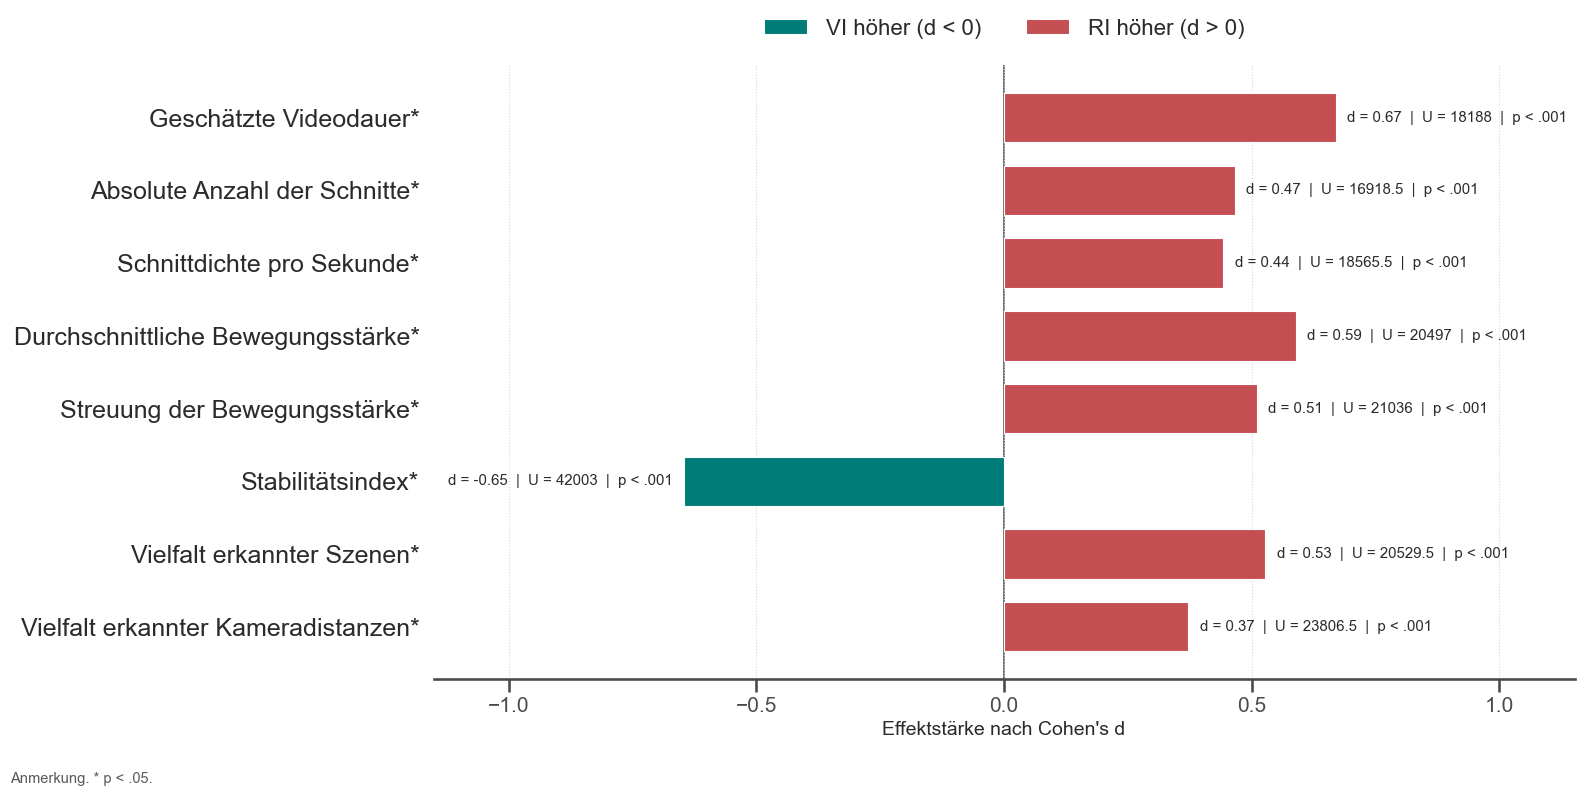

In [18]:
plot_supercategory_effects('Strukturale Inszenierung und visuelle Dynamik')


### Bildtechnik


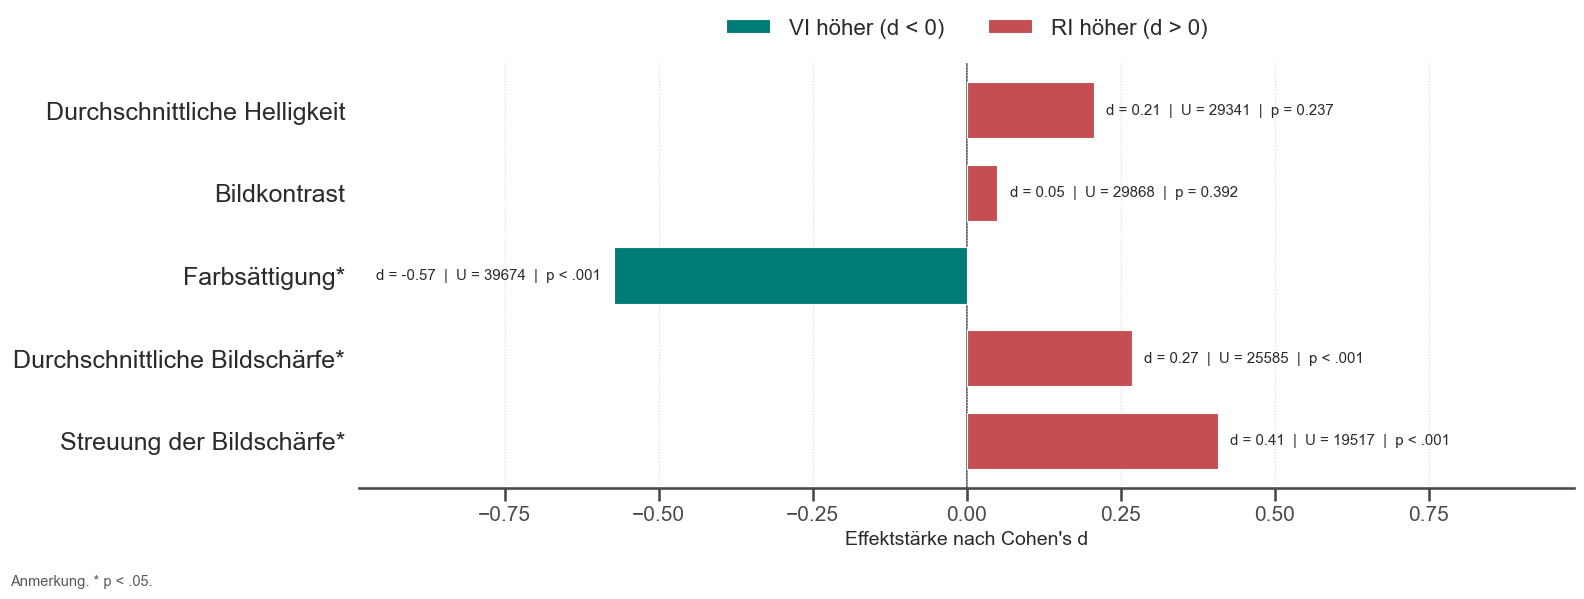

In [19]:
plot_supercategory_effects('Bildtechnische Merkmale')


### Ästhetik


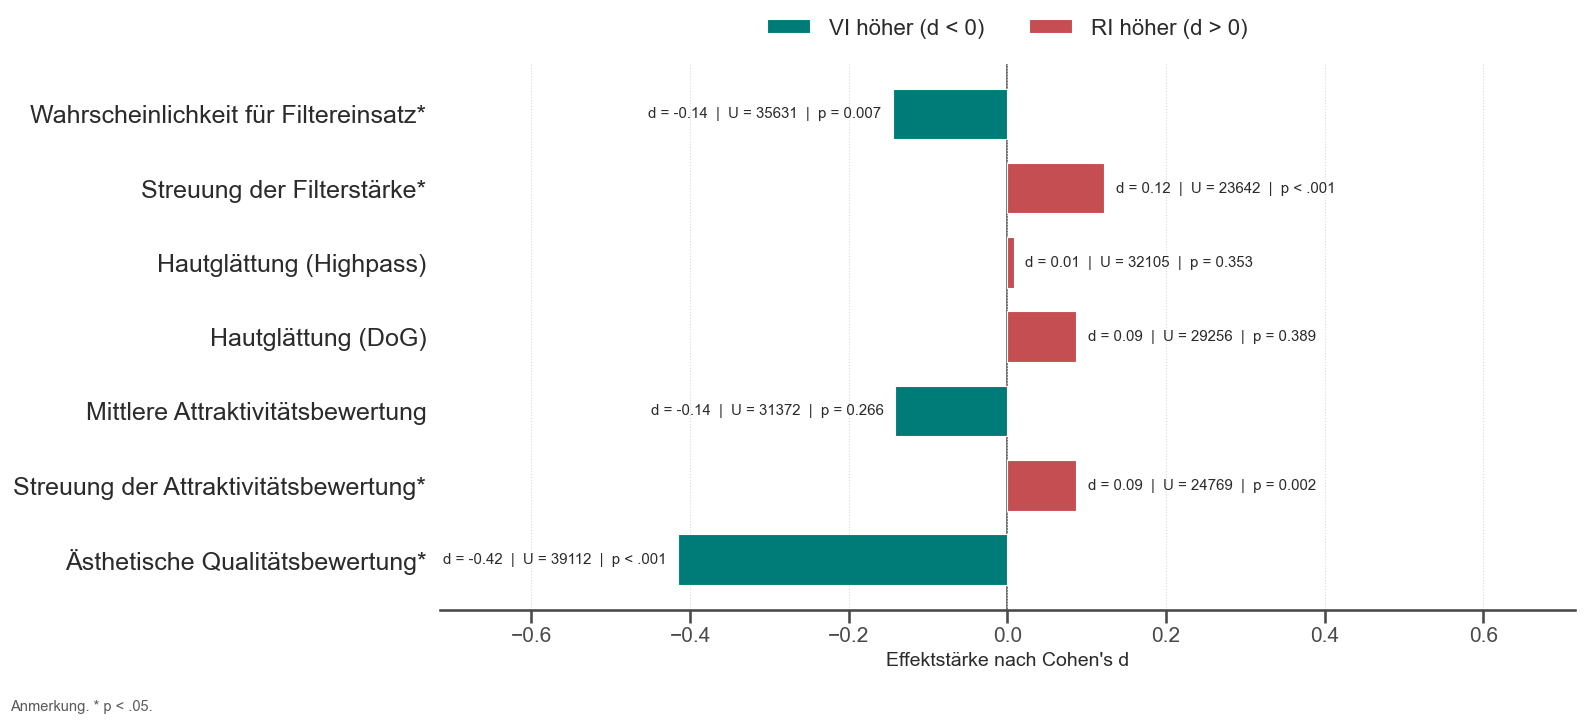

In [20]:
plot_supercategory_effects('Ästhetische Qualität und visuelle Optimierung')


### Emotion/Präsenz


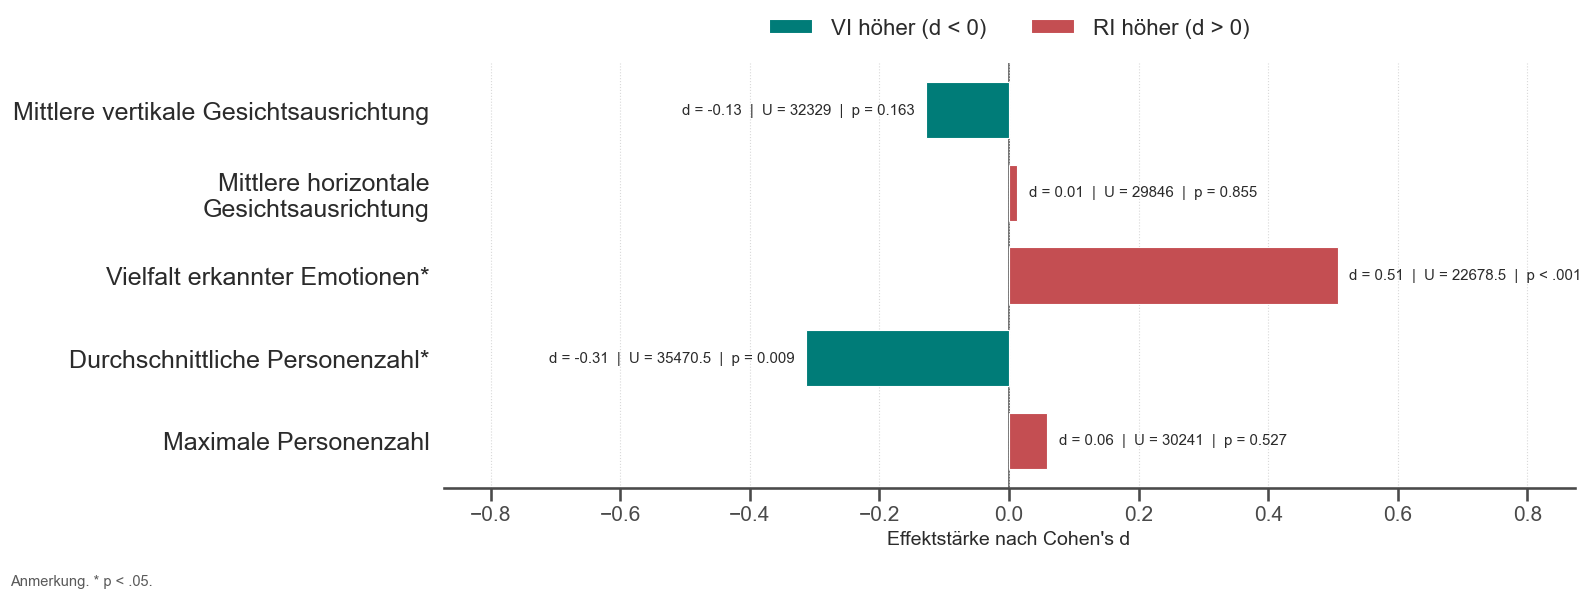

In [23]:
plot_supercategory_effects('Emotionale und soziale Präsenz')


## 4. Zusammenhang mit Engagement

### 4.1 Korrelationsüberblick

Es werden Spearman-Korrelationen berechnet. In der Heatmap werden nur signifikante Zusammenhänge farbig hervorgehoben.


In [14]:
corr_rows = []
for (feature_group, metric_name, metric_label), sub in numeric_long.groupby(['feature_group', 'metric_name', 'metric_label']):
    tmp = sub[['video_engagement_rate', 'feature_value_numeric']].dropna()
    if len(tmp) < 10:
        continue
    rho, p_value = spearmanr(tmp['feature_value_numeric'], tmp['video_engagement_rate'])
    corr_rows.append({
        'Kategorie': metric_label,
        'feature_group': feature_group,
        'metric_name': metric_name,
        'rho_engagement': rho,
        'p_engagement': p_value,
        'signifikant_05': p_value < 0.05,
    })

corr_df = pd.DataFrame(corr_rows).sort_values(['signifikant_05', 'p_engagement'], ascending=[False, True])
corr_df.to_csv(OUTPUT_ENGAGEMENT_CORR_CSV, index=False)
display(corr_df.head(30).round(4))
print(f'Korrelationsuebersicht gespeichert: {OUTPUT_ENGAGEMENT_CORR_CSV}')


,Kategorie,feature_group,metric_name,rho_engagement,p_engagement,signifikant_05
3,Gesichtsorientierung | Mittlere vertikale Gesi...,angle_face_orientation,face_pitch_mean,-0.2193,0.0000,True
20,Schnittdynamik | Bildrate des Videos,cuts,video_fps,0.1864,0.0000,True
18,Schnittdynamik | Analysierte Frames,cuts,frames_scanned,0.1561,0.0005,True
1,Ästhetische Gesamtqualität | Anzahl ästhetisch...,aesthetic_quality,aesthetic_quality_scored_frames,0.1426,0.0014,True
8,Körperhaltung und Pose | Anteil erkannter Pose...,body_pose,detected_pose_frames,0.1426,0.0014,True
21,Emotionale Gesichtswirkung | Anteil emotional ...,face_emotion,detected_emotion_frames,0.1426,0.0014,True
19,Schnittdynamik | Geschätzte Videodauer,cuts,video_duration_seconds_est,0.1394,0.0018,True
24,Szenenklassifikation | Vielfalt erkannter Szenen,scene_classification,scene_unique_labels,0.1393,0.0018,True
25,Hauttextur und Hautglättung | Anzahl auswertba...,skin_smoothness,detected_skin_face_frames,0.1133,0.0112,True
26,Hauttextur und Hautglättung | Hautglättung (DoG),skin_smoothness,skin_smoothness_dog_index,-0.1120,0.0126,True


Korrelationsübersicht gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/99_AI_AND_REAL_TIKTOK_VIDEOS_engagement_correlations.csv


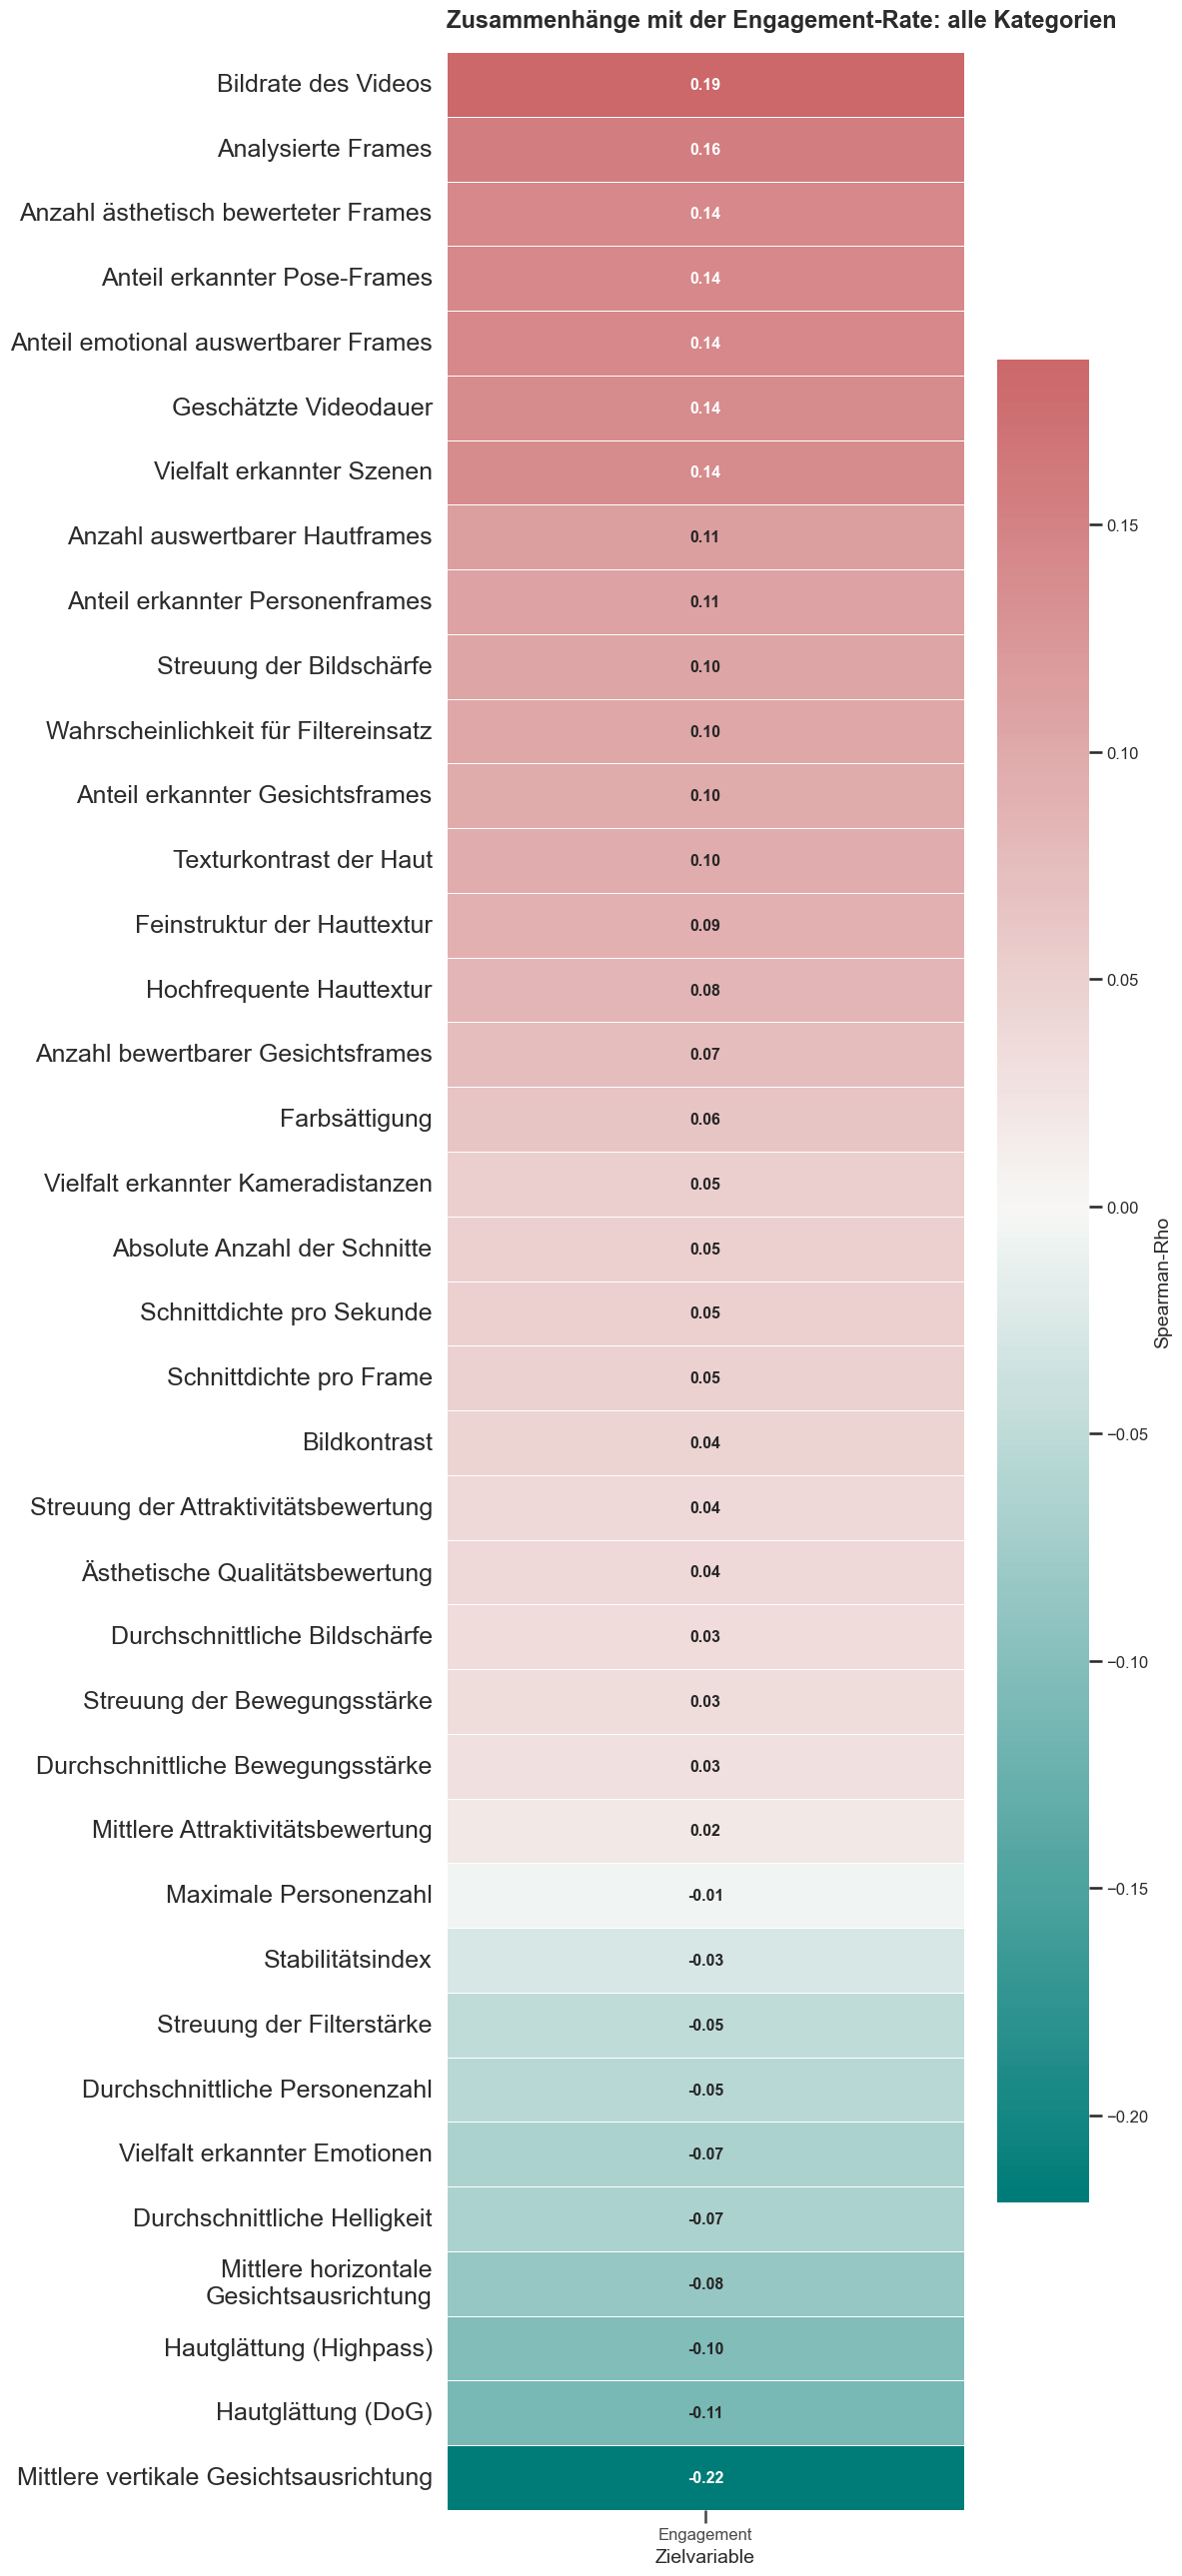

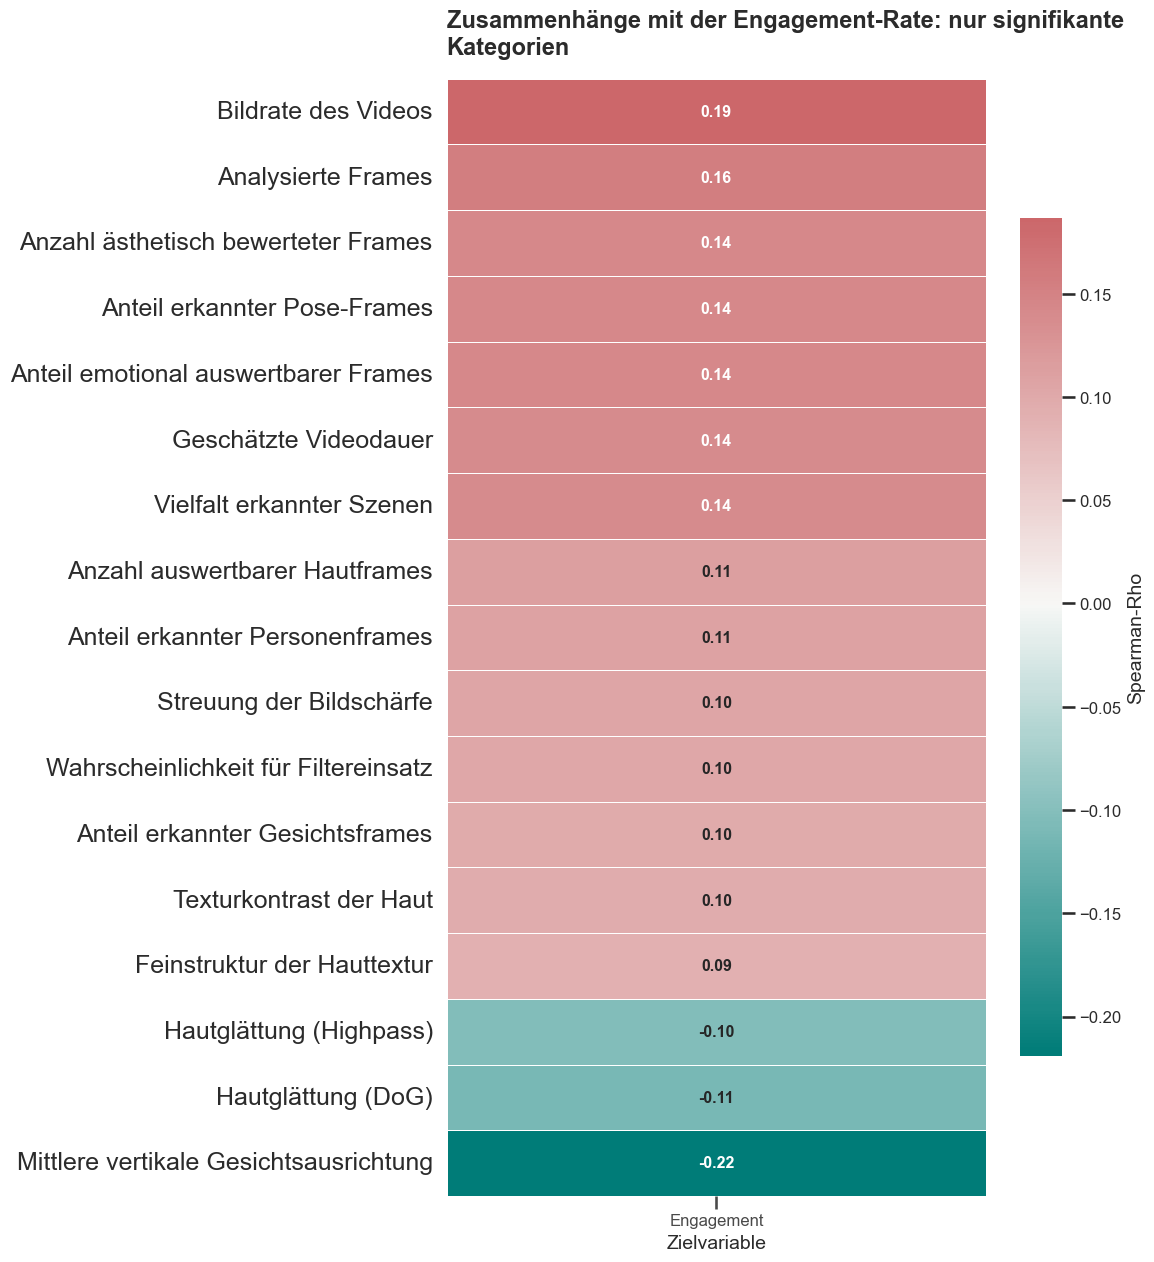

In [15]:
corr_df_all = corr_df.copy().sort_values('rho_engagement', ascending=False)
corr_df_sig = corr_df_all[corr_df_all['signifikant_05']].copy()

def plot_corr_heatmap(source_df: pd.DataFrame, title: str):
    if source_df.empty:
        print(f'Keine Daten für: {title}')
        return
    heatmap_df = source_df.copy()
    heatmap_df['Kategorie_plot'] = heatmap_df['Kategorie'].map(
        lambda value: '\n'.join(textwrap.wrap(feature_only_label(value), width=38))
    )
    heatmap_mat = heatmap_df.set_index('Kategorie_plot')[['rho_engagement']].rename(columns={'rho_engagement': 'Engagement'})
    fig, ax = plt.subplots(figsize=(11.5, max(8.5, 0.64 * len(heatmap_mat) + 2.2)))
    sns.heatmap(
        heatmap_mat,
        cmap=DIVERGING_CMAP,
        center=0,
        linewidths=0.5,
        linecolor='white',
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize': 11.5, 'fontweight': 'semibold'},
        cbar_kws={'label': 'Spearman-Rho', 'shrink': 0.75},
        ax=ax,
    )
    ax.set_title('\n'.join(textwrap.wrap(title, width=55)), loc='left', pad=18, weight='semibold', fontsize=17)
    ax.set_xlabel('Zielvariable')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=18, length=0, pad=10)
    ax.tick_params(axis='x', labelsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_corr_heatmap(corr_df_all, 'Zusammenhänge mit der Engagement-Rate: alle Kategorien')
plot_corr_heatmap(corr_df_sig, 'Zusammenhänge mit der Engagement-Rate: nur signifikante Kategorien')



### 4.2 Optionale Fokus-Scatterplots

Nur für besonders relevante Variablen. Standardmäßig werden die drei stärksten signifikanten Korrelationen genutzt. Die Liste kann unten auch manuell gesetzt werden.


In [16]:
FOCUS_SCATTER_METRICS = []

if not FOCUS_SCATTER_METRICS:
    FOCUS_SCATTER_METRICS = corr_df.loc[corr_df['signifikant_05']].assign(abs_rho=lambda d: d['rho_engagement'].abs()).sort_values('abs_rho', ascending=False)['Kategorie'].head(3).tolist()

focus_df = corr_df[corr_df['Kategorie'].isin(FOCUS_SCATTER_METRICS)].copy()
display(focus_df.round(4))


,Kategorie,feature_group,metric_name,rho_engagement,p_engagement,signifikant_05
3,Gesichtsorientierung | Mittlere vertikale Gesi...,angle_face_orientation,face_pitch_mean,-0.2193,0.0000,True
20,Schnittdynamik | Bildrate des Videos,cuts,video_fps,0.1864,0.0000,True
18,Schnittdynamik | Analysierte Frames,cuts,frames_scanned,0.1561,0.0005,True


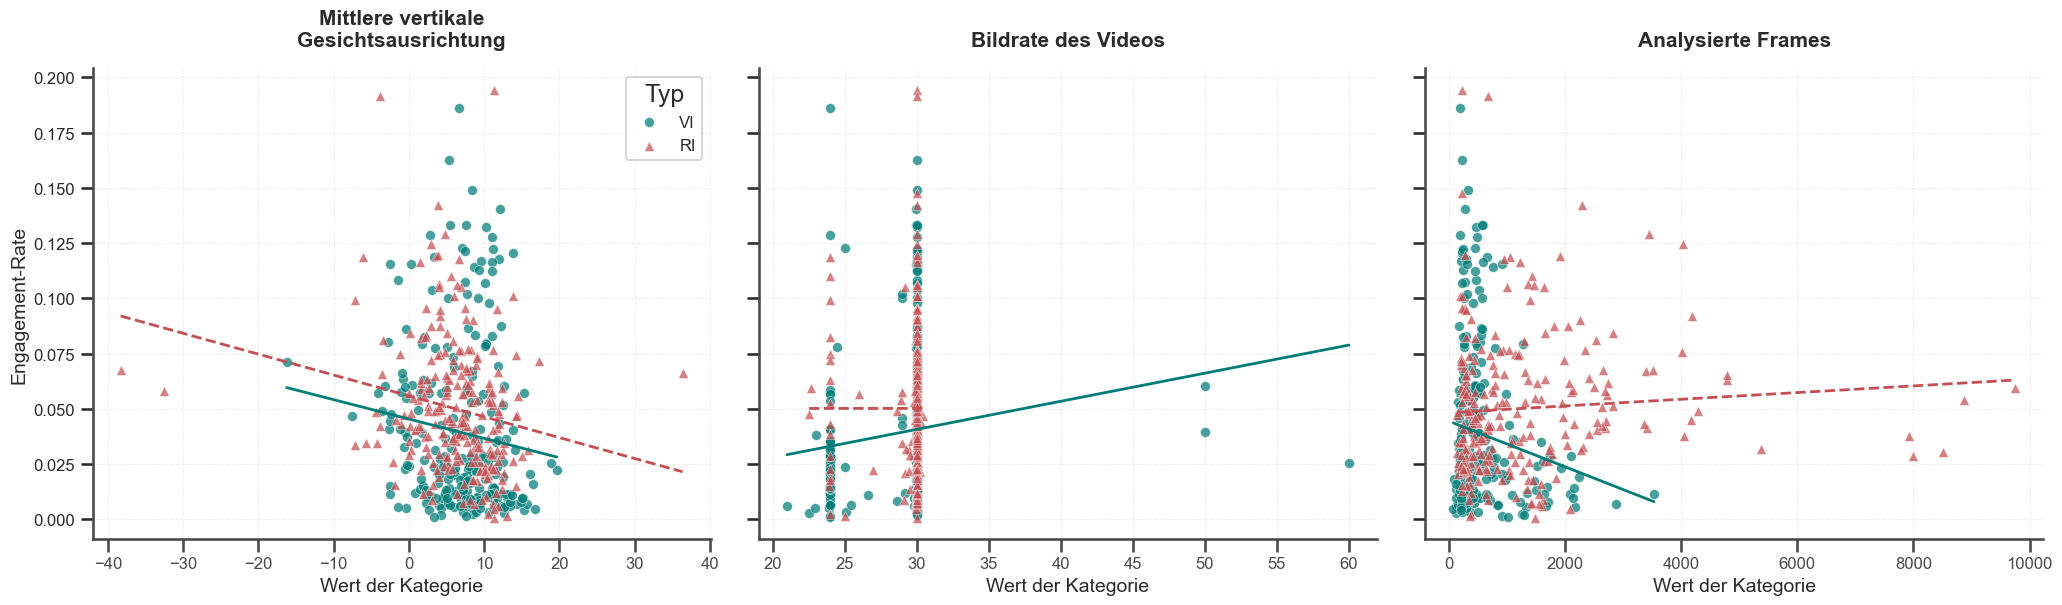

In [17]:
if focus_df.empty:
    print('Keine Fokus-Scatterplots ausgewaehlt.')
else:
    n = len(focus_df)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6.4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, focus_df.iterrows()):
        sub = numeric_long[(numeric_long['feature_group'] == row['feature_group']) & (numeric_long['metric_name'] == row['metric_name'])]
        for typ, marker, linestyle in [('VI', 'o', '-'), ('RI', '^', '--')]:
            tmp = sub[sub['plot_typ'] == typ]
            sns.scatterplot(
                data=tmp,
                x='feature_value_numeric',
                y='video_engagement_rate',
                color=PALETTE[typ],
                marker=marker,
                alpha=0.72,
                edgecolor='white',
                linewidth=0.4,
                s=50,
                ax=ax,
                label=typ,
            )
            sns.regplot(
                data=tmp,
                x='feature_value_numeric',
                y='video_engagement_rate',
                scatter=False,
                ci=None,
                color=PALETTE[typ],
                line_kws={'linewidth': 2.0, 'linestyle': linestyle},
                ax=ax,
            )

        ax.set_title('\n'.join(textwrap.wrap(feature_only_label(row['Kategorie']), width=30)), pad=16, weight='semibold', fontsize=15)
        ax.set_xlabel('Wert der Kategorie')
        ax.set_ylabel('Engagement-Rate')
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(alpha=0.65)
        sns.despine(ax=ax, top=True, right=True)

    axes[0].legend(title='Typ', frameon=True)
    for ax in axes[1:]:
        ax.legend([], [], frameon=False)
    plt.tight_layout(pad=1.5)
    plt.show()



## 5. Hauptmodell und standardisierte Koeffizienten

Das Hauptmodell nutzt numerische Variablen mit signifikantem Zusammenhang zum Engagement. Stark redundante Variablen werden vorab entfernt.


In [18]:
regression_candidates = corr_df.loc[corr_df['signifikant_05'], 'Kategorie'].tolist()

regression_wide = wide_df[['video_id', 'video_engagement_rate']].copy()
regression_label_map = {}
for label in regression_candidates:
    sub = corr_df[corr_df['Kategorie'] == label].iloc[0]
    col_name = f"{sub['feature_group']}__{sub['metric_name']}"
    if col_name in wide_df.columns:
        regression_wide[label] = pd.to_numeric(wide_df[col_name], errors='coerce')
        regression_label_map[label] = col_name

regression_wide = regression_wide.dropna(subset=['video_engagement_rate'])
for col in regression_wide.columns[2:]:
    regression_wide[col] = regression_wide[col].fillna(regression_wide[col].median())

candidate_cols = [col for col in regression_wide.columns if col not in ['video_id', 'video_engagement_rate']]
corr_matrix = regression_wide[candidate_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [column for column in upper.columns if any(upper[column] > 0.85)]
model_cols = [col for col in candidate_cols if col not in drop_cols]

X = regression_wide[model_cols].copy()
y = regression_wide['video_engagement_rate'].copy()

X_std = X.apply(standardize)
y_std = standardize(y)

beta_values = np.linalg.pinv(X_std.to_numpy()) @ y_std.to_numpy()
beta_df = pd.DataFrame({'Kategorie': model_cols, 'beta_std': beta_values})
beta_df = beta_df.merge(corr_df[['Kategorie', 'p_engagement']], on='Kategorie', how='left')
beta_df = beta_df.sort_values('beta_std')
beta_df.to_csv(OUTPUT_REGRESSION_CSV, index=False)

print('Entfernt wegen hoher Kollinearität (> .85):', drop_cols)
display(beta_df.round(4))
print(f'Regressionsuebersicht gespeichert: {OUTPUT_REGRESSION_CSV}')


Entfernt wegen hoher Kollinearität (> .85): ['Ästhetische Gesamtqualität | Anzahl ästhetisch bewerteter Frames', 'Körperhaltung und Pose | Anteil erkannter Pose-Frames', 'Emotionale Gesichtswirkung | Anteil emotional auswertbarer Frames', 'Schnittdynamik | Geschätzte Videodauer', 'Hauttextur und Hautglättung | Anzahl auswertbarer Hautframes', 'Hauttextur und Hautglättung | Hautglättung (Highpass)', 'Gesichtsorientierung | Anteil erkannter Gesichtsframes']


/Users/hannahernstberger/Documents/Master_/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/hannahernstberger/Documents/Master_/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/hannahernstberger/Documents/Master_/venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_20021/1976546087.py:28: RuntimeWarning: divide by zero encountered in matmul
  beta_values = np.linalg.pinv(X_std.to_numpy()) @ y_std.to_numpy()
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_20021/1976546087.py:28: RuntimeWarning: overflow encountered in matmul
  beta_values = np.linalg.pinv(X_std.to_numpy()) @ y_std.to_numpy()
/var/folders/xv/tws3wcdj24b6nwt9_f_

,Kategorie,beta_std,p_engagement
0,Gesichtsorientierung | Mittlere vertikale Gesi...,-0.1524,0.0000
6,Bildschärfe | Streuung der Bildschärfe,-0.0458,0.0200
9,Hauttextur und Hautglättung | Feinstruktur der...,-0.0333,0.0437
4,Hauttextur und Hautglättung | Hautglättung (DoG),-0.0161,0.0126
7,Filter-/Artefaktmerkmale | Wahrscheinlichkeit ...,-0.0077,0.0213
2,Schnittdynamik | Analysierte Frames,0.0065,0.0005
5,Personenanzahl | Anteil erkannter Personenframes,0.0085,0.0142
8,Hauttextur und Hautglättung | Texturkontrast d...,0.0563,0.0311
3,Szenenklassifikation | Vielfalt erkannter Szenen,0.0730,0.0018
1,Schnittdynamik | Bildrate des Videos,0.1200,0.0000


Regressionsübersicht gespeichert: /Users/hannahernstberger/Documents/Master_/data/04_analysis_results/visual_features/99_AI_AND_REAL_TIKTOK_VIDEOS_regression_betas.csv


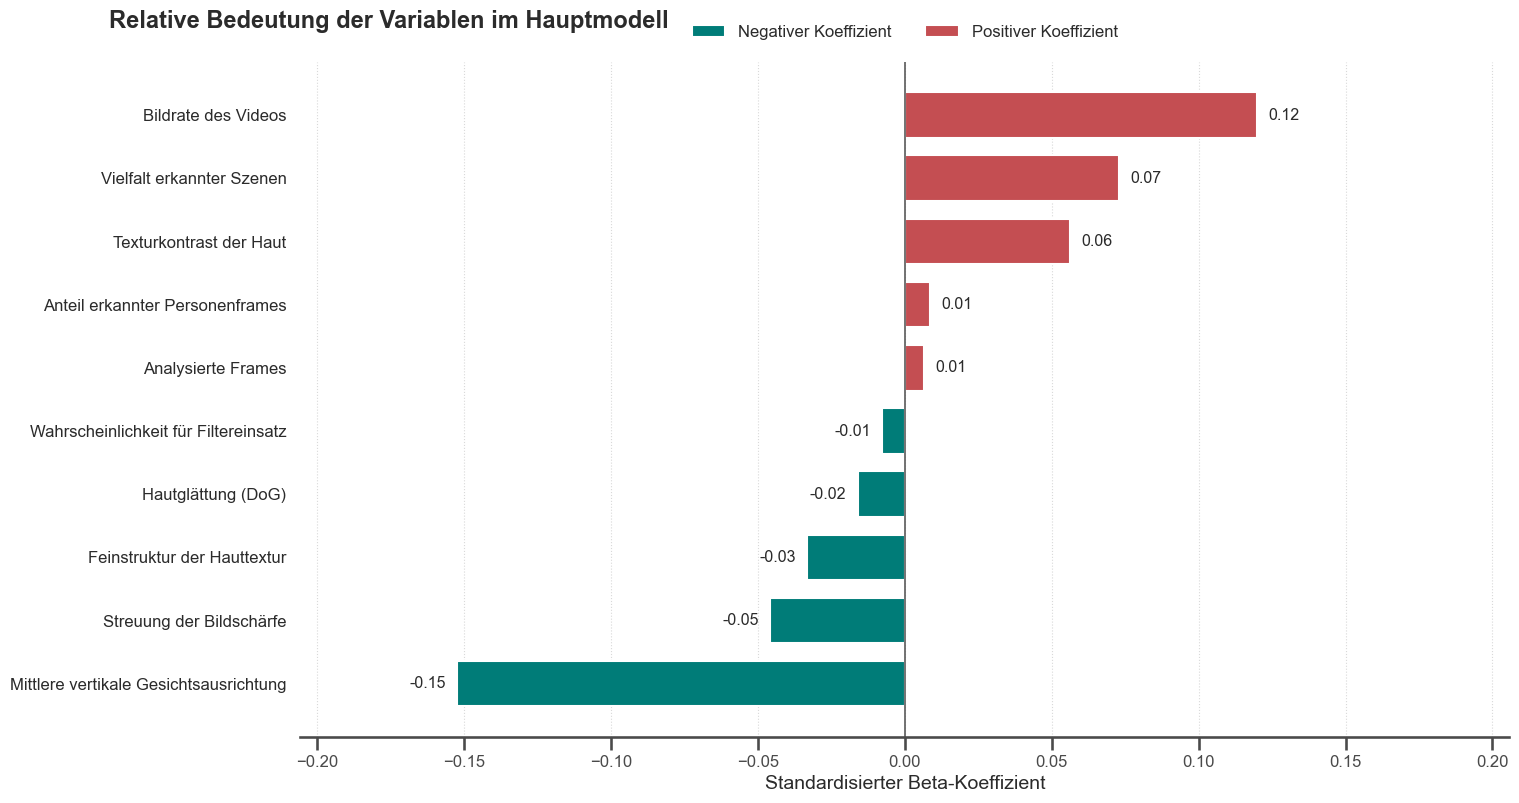

In [19]:
plot_beta_df = beta_df.copy()
plot_beta_df['Kategorie_plot'] = plot_beta_df['Kategorie'].map(
    lambda value: '\n'.join(textwrap.wrap(feature_only_label(value), width=38))
)
fig, ax = plt.subplots(figsize=(15.5, max(6.5, 0.72 * len(plot_beta_df) + 2.2)))
bar_colors = np.where(plot_beta_df['beta_std'] >= 0, PALETTE['RI'], PALETTE['VI'])
bars = ax.barh(plot_beta_df['Kategorie_plot'], plot_beta_df['beta_std'], color=bar_colors, edgecolor='white', height=0.72)
max_abs = max(plot_beta_df['beta_std'].abs().max(), 0.05)
ax.set_xlim(-1.35 * max_abs, 1.35 * max_abs)
ax.axvline(0, color=NEUTRAL_COLORS['zero'], linewidth=1.2)
for bar, value in zip(bars, plot_beta_df['beta_std']):
    offset = 0.025 * max_abs if value >= 0 else -0.025 * max_abs
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=11.5)
legend_handles = [
    Patch(facecolor=PALETTE['VI'], label='Negativer Koeffizient'),
    Patch(facecolor=PALETTE['RI'], label='Positiver Koeffizient'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False)
fig.suptitle('Relative Bedeutung der Variablen im Hauptmodell', x=0.08, y=0.86, ha='left', weight='semibold', fontsize=17)
ax.set_xlabel('Standardisierter Beta-Koeffizient')
ax.set_ylabel('')
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=12, length=0, pad=10)
ax.tick_params(axis='x', labelsize=12)
sns.despine(ax=ax, top=True, right=True, left=True)
plt.tight_layout(rect=[0, 0, 1, 0.93], pad=1.4)
plt.show()
